In [1]:
import pandas as pd
import pymc as pm
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.lines as mlines
import matplotlib.cm as cm
import scipy.stats as sts
import arviz as az
import seaborn as sns

In [2]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

In [3]:
data = pd.read_csv('sports-attendance-data.csv')
data.head(15)

,team,day,attendance
0,River Plate,Monday,32729.0
1,River Plate,Saturday,31915.0
2,River Plate,Thursday,NaN
3,River Plate,Thursday,31512.0
4,River Plate,Friday,23361.0
5,River Plate,Monday,44135.0
6,River Plate,Thursday,7217.0
7,River Plate,Tuesday,NaN
8,River Plate,Sunday,25233.0
9,River Plate,Tuesday,11179.0


## 1. Data Pre-Processing

Data exists for 12 separate teams and 7 days of the week.


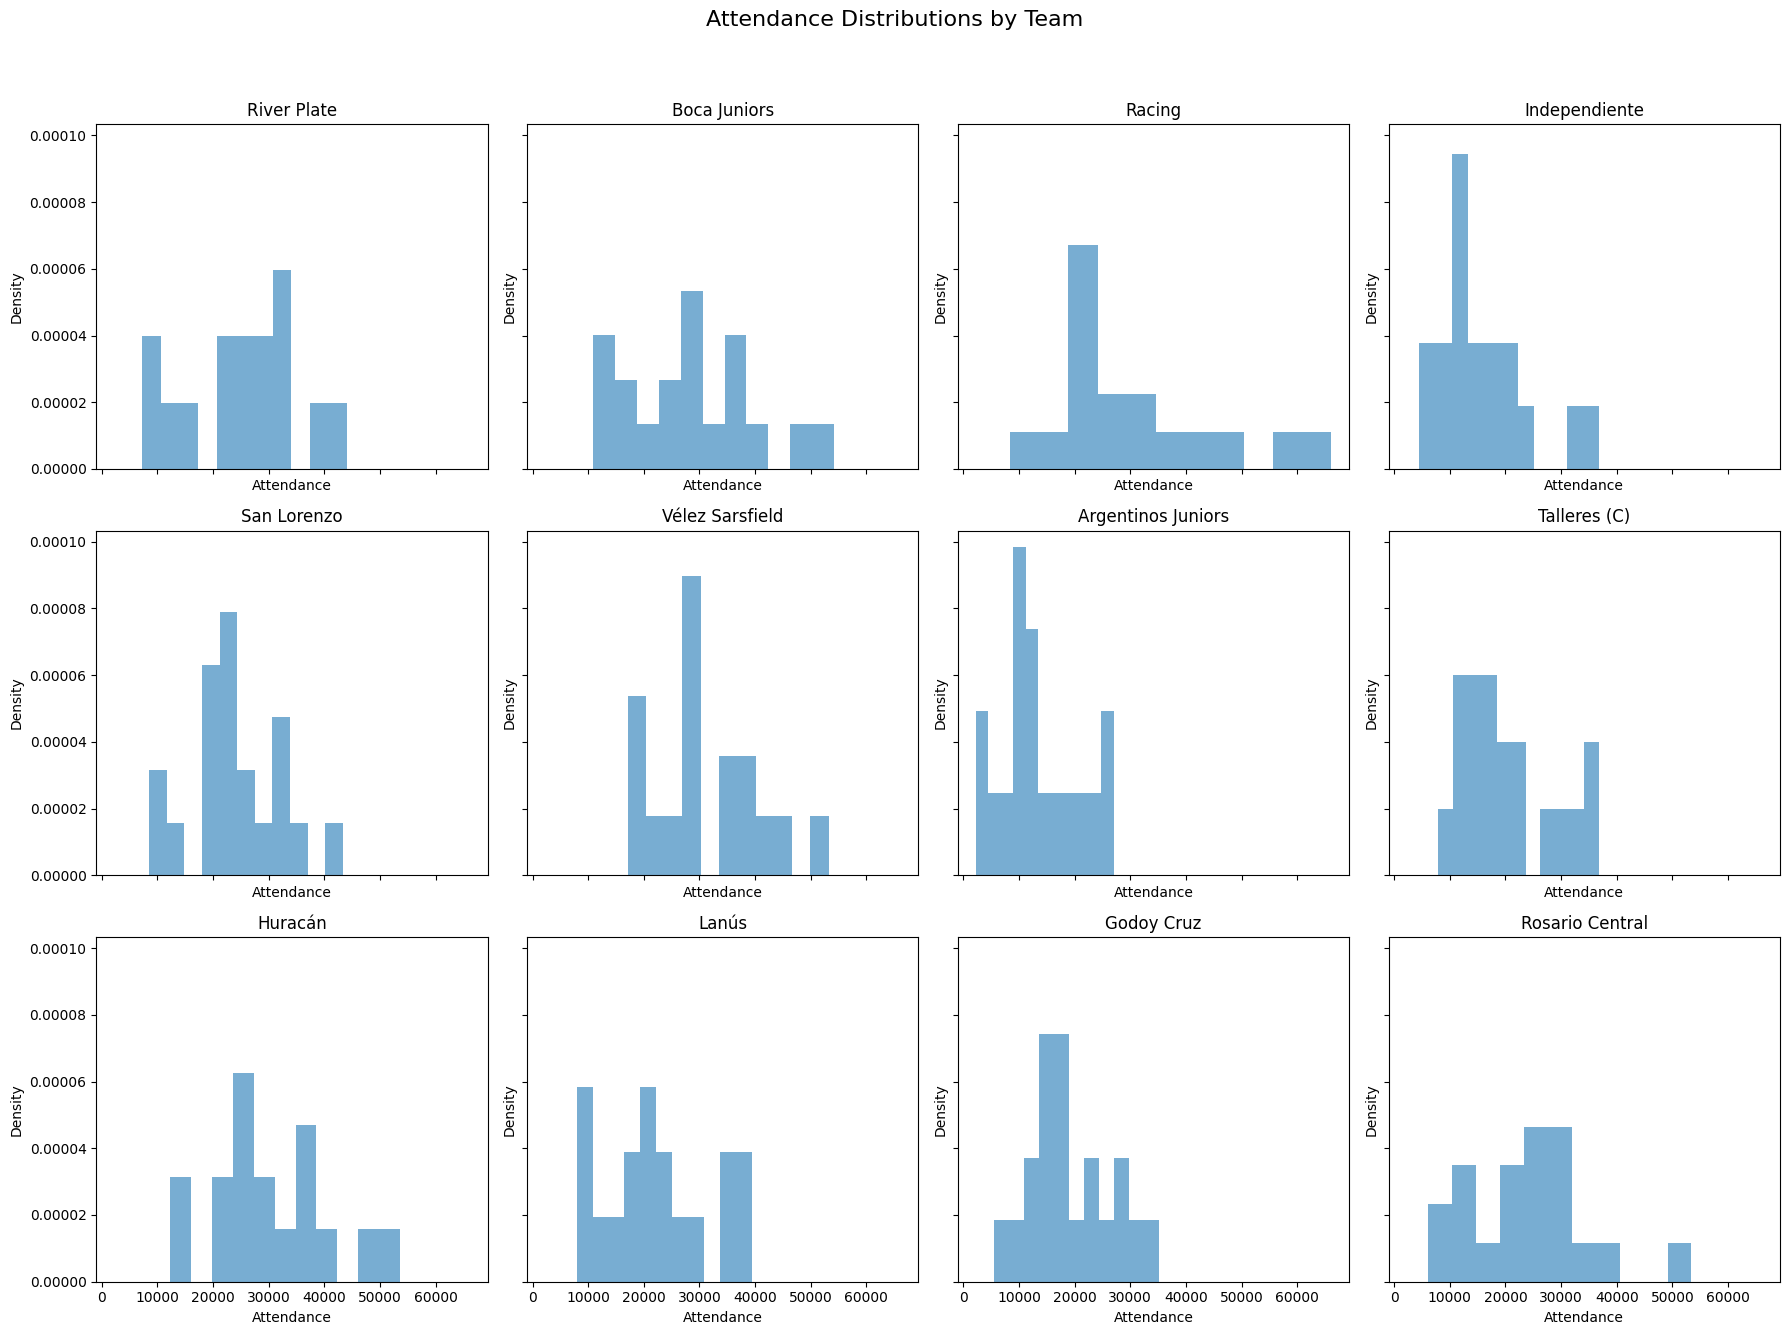

In [4]:
# visualizing the data by attendance
team_names = data['team'].unique()
print(f"Data exists for {len(team_names)} separate teams ", end='')
weekdays = data['day'].unique()
print(f"and {len(weekdays)} days of the week.")

fig, axes = plt.subplots(3, 4, figsize=(18, 14), sharey=True, sharex=True)
axes_flat = axes.flatten()

for ax, team_name in zip(axes_flat, team_names):
    y = data.loc[data['team'] == team_name, 'attendance'].dropna()

    ax.hist(y, alpha=0.6, bins=11, density=True)
    ax.set_title(team_name)
    ax.set_xlabel('Attendance')
    ax.set_ylabel('Density')

# If there are more subplots than teams, hide the unused ones
for ax in axes_flat[len(team_names):]:
    ax.set_visible(False)

fig.suptitle('Attendance Distributions by Team', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Data exists for 7 days of the week.


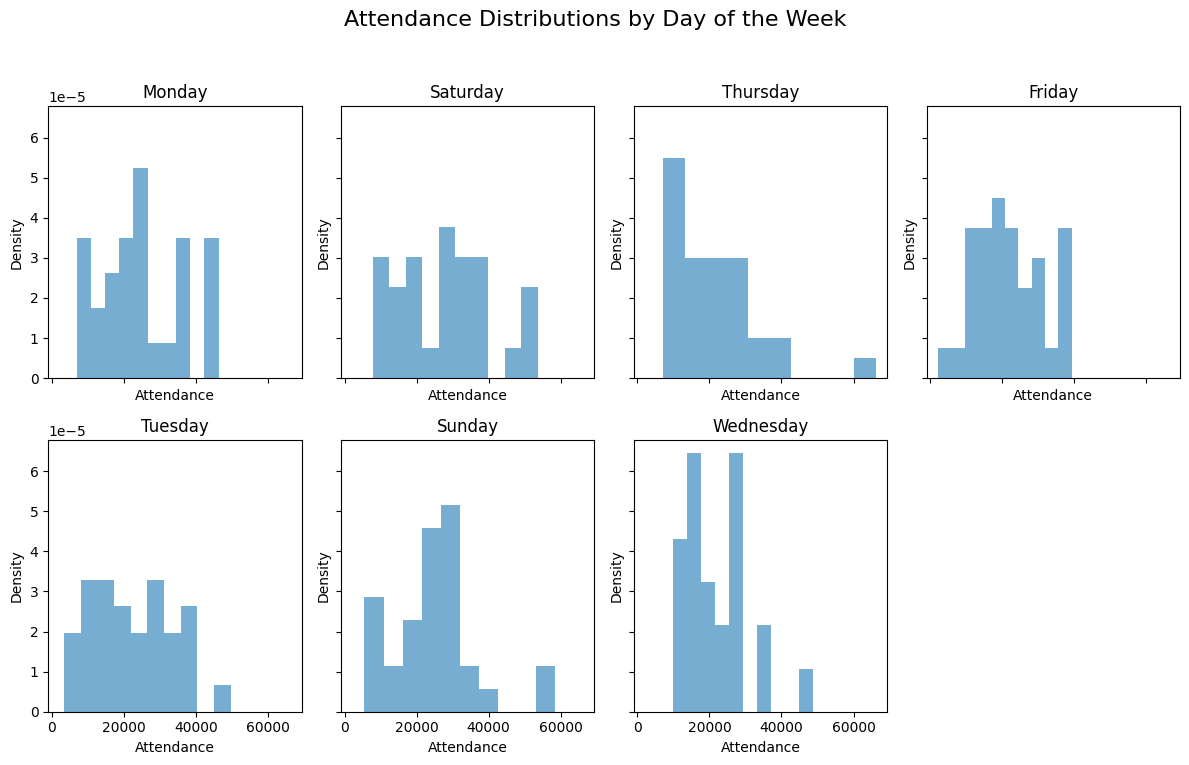

In [5]:
# visualizing the data by day of the week
weekdays = data['day'].unique()
print(f"Data exists for {len(weekdays)} days of the week.")

# 7 subplots in a 3x3 grid (2 left empty), sharing x/y axes
fig, axes = plt.subplots(2, 4, figsize=(12, 8), sharex=True, sharey=True)
axes_flat = axes.flatten()

for ax, day in zip(axes_flat, weekdays):
    y = data.loc[data['day'] == day, 'attendance'].dropna()

    ax.hist(y, alpha=0.6, density=True)
    ax.set_title(str(day))
    ax.set_xlabel('Attendance')
    ax.set_ylabel('Density')

# hide any unused subplots (since we only have 7 days)
for ax in axes_flat[len(weekdays):]:
    ax.set_visible(False)

fig.suptitle('Attendance Distributions by Day of the Week', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


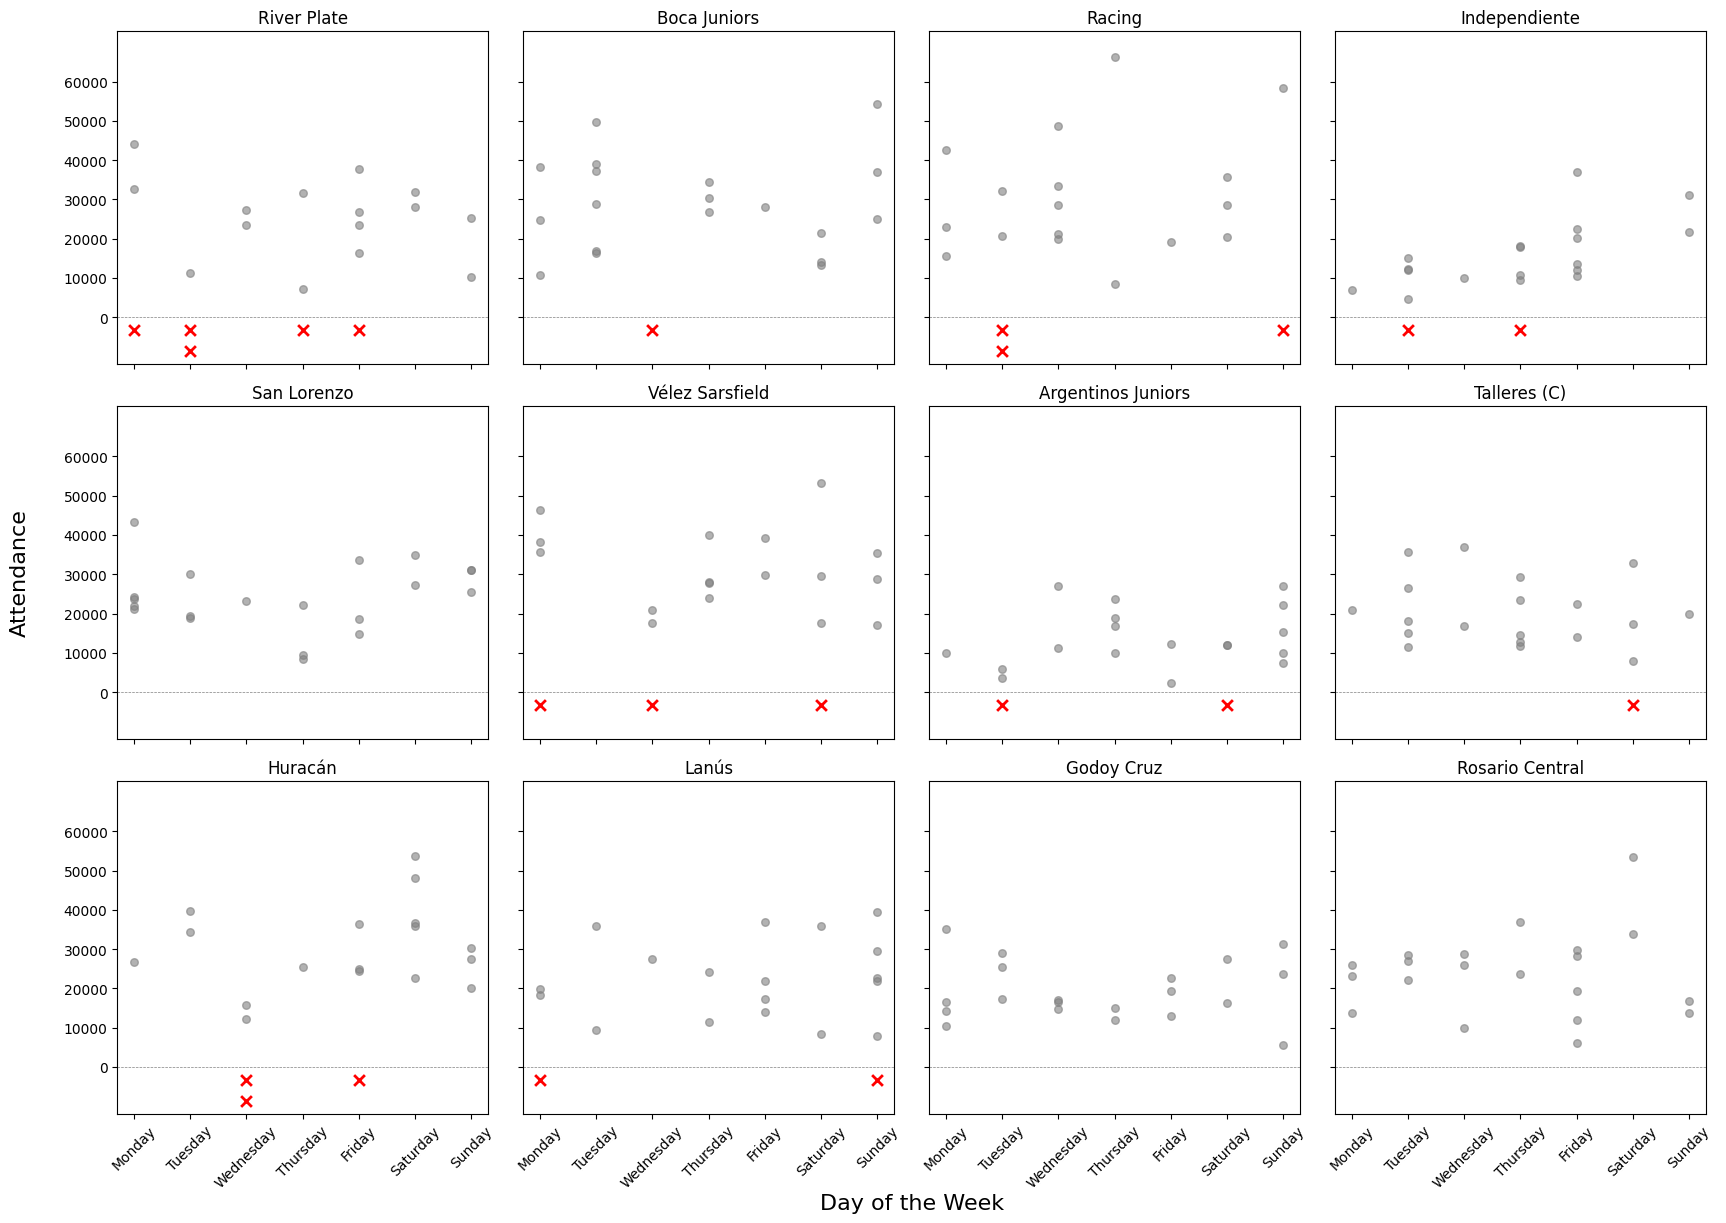

In [6]:
# creating an overview of where the missing datapoints are
file_name = 'sports-attendance-data.csv'
data = pd.read_csv(file_name)

# putting the days of the week in order
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_map = {day: i for i, day in enumerate(weekday_order)}

# separating missing data for the plot
data_cleaned = data.dropna(subset=['attendance']).copy()
data_missing = data[data['attendance'].isna()].copy()

# mapping days to integers to plot in order
data_cleaned['day_idx'] = data_cleaned['day'].map(weekday_map)
data_missing['day_idx'] = data_missing['day'].map(weekday_map)

# counting how much data is missing for each day & team
data_missing['stack_idx'] = data_missing.groupby(['team', 'day']).cumcount()

# determining axis limits
team_names = data['team'].unique()
max_attendance = data_cleaned['attendance'].max()
plot_bottom_start = -max_attendance * 0.05
stack_step = max_attendance * 0.08
max_stack_depth = data_missing['stack_idx'].max() if not data_missing.empty else 0
lowest_y = plot_bottom_start - (max_stack_depth * stack_step)
ylim_bottom = lowest_y - (max_attendance * 0.05)
ylim_top = max_attendance * 1.1

# create plot
fig, axes = plt.subplots(3, 4, figsize=(18, 14), sharey=True, sharex=True)
axes_flat = axes.flatten()

# for each team (each plot)
for i, team in enumerate(team_names):
    ax = axes_flat[i]
    team_data_cleaned = data_cleaned[data_cleaned['team'] == team]
    team_data_missing = data_missing[data_missing['team'] == team]

    # plot observed data
    ax.scatter(team_data_cleaned['day_idx'], team_data_cleaned['attendance'],
               alpha=0.6, c='grey', s=30, marker='o', label='Observed')

    # leave a marker for missing data
    if not team_data_missing.empty:
        y_positions = plot_bottom_start - (team_data_missing['stack_idx'] * stack_step)
        ax.scatter(team_data_missing['day_idx'], y_positions,
                   color='red', marker='x', s=60, linewidth=2, label='Missing')


    ax.set_title(team)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.5)

    # x ticks
    ax.set_xticks(range(len(weekday_order)))
    ax.set_xticklabels(weekday_order, rotation=45)

# y ticks
plt.ylim(bottom=ylim_bottom, top=ylim_top)
y_ticks = np.arange(0, max_attendance + 1, 10000)
axes_flat[0].set_yticks(y_ticks)
fig.add_subplot(111, frameon=False)

# exclude ticks for all plots apart from the edge ones
plt.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)
plt.xlabel('Day of the Week', fontsize=16, labelpad=40)
plt.ylabel('Attendance', fontsize=16, labelpad=40)
plt.tight_layout(rect=[0, 0.03, 1, 0.97])

In [7]:
# transforming the data
data_enc = data.copy()
days_dict = {'Monday': 0, 'Tuesday': 1, 'Wednesday': 2, 'Thursday': 3,
             'Friday': 4, 'Saturday': 5, 'Sunday': 6}
data_enc['team_idx'] = data_enc['team'].apply(lambda x: team_names.tolist().index(x))
data_enc['day_idx'] = data_enc['day'].apply(lambda x: days_dict[x])
data_enc.head(200)

,team,day,attendance,team_idx,day_idx
0,River Plate,Monday,32729.0,0,0
1,River Plate,Saturday,31915.0,0,5
2,River Plate,Thursday,NaN,0,3
3,River Plate,Thursday,31512.0,0,3
4,River Plate,Friday,23361.0,0,4
...,...,...,...,...,...
195,Lanús,Thursday,24278.0,9,3
196,Lanús,Monday,18323.0,9,0
197,Lanús,Tuesday,9413.0,9,1
198,Lanús,Friday,17314.0,9,4


## 2. Model 1: Complete Pooling



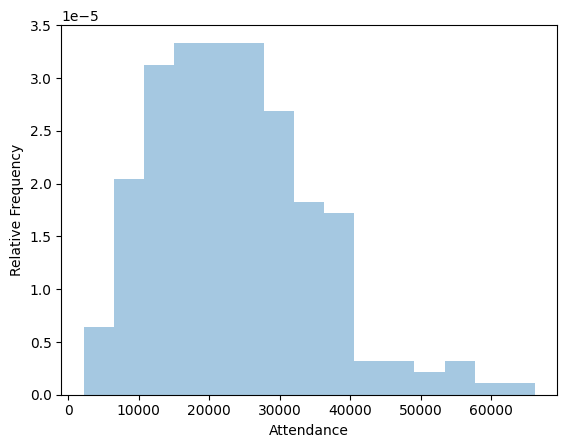

In [8]:
# we assume that all data points come from a single likelihood function
# in this case, x is discrete (day of the week)
plot_data = data_enc.sort_values(by='day')
plt.hist(plot_data['attendance'], bins=15, density=True, alpha=0.4)
plt.xlabel('Attendance')
plt.ylabel('Relative Frequency')
plt.show()

In [9]:
# sampling from model 1
with pm.Model() as model_1:
  mu = pm.HalfNormal('mu', sigma=20000)
  alpha = pm.Exponential('alpha', 1)
  attendance = pm.NegativeBinomial('attendance', mu=mu, alpha=alpha, observed=data_enc['attendance'].dropna())
  samples_1 = pm.sample(chains=4, tune=1000, target_accept=0.9, random_seed=RANDOM_SEED)

Output()

In [10]:
# posterior
variables = ['mu', 'alpha']
az.summary(samples_1, var_names=variables)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu,23698.896,795.629,22267.556,25270.736,12.846,12.782,3874.0,2718.0,1.0
alpha,3.938,0.361,3.326,4.682,0.006,0.005,3851.0,2894.0,1.0


/tmp/ipython-input-2469833166.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('Blues', 4)


array([<Axes: title={'center': 'mu'}, xlabel='Rank (all chains)', ylabel='Chain'>,
       <Axes: title={'center': 'alpha'}, xlabel='Rank (all chains)', ylabel='Chain'>],
      dtype=object)

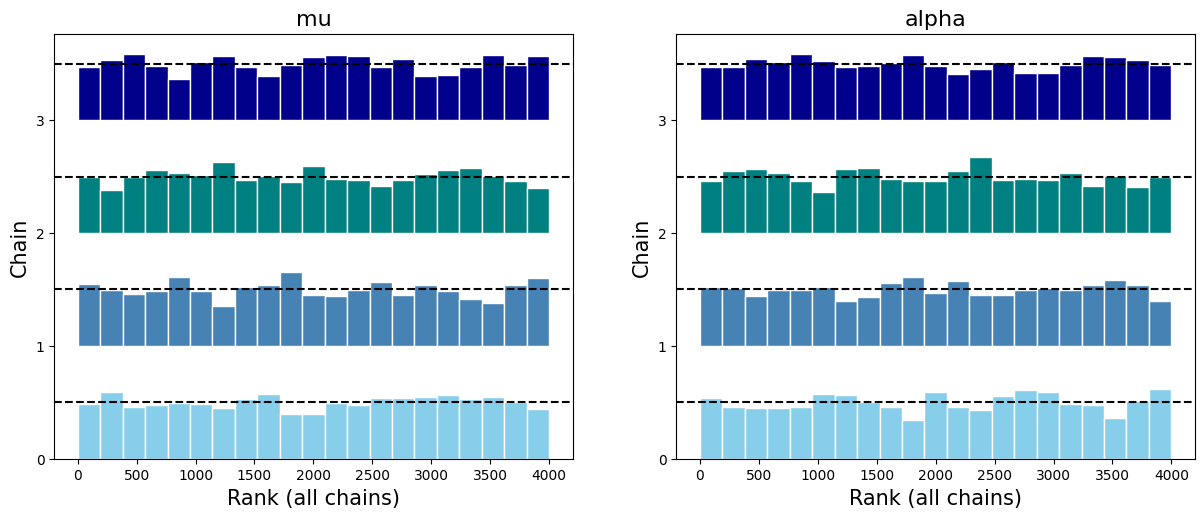

In [11]:
colors = cm.get_cmap('Blues', 4)
print(colors)
az.plot_rank(samples_1, var_names=variables, colors=['skyblue', 'steelblue', 'teal', 'darkblue'])

<Axes: xlabel='mu', ylabel='alpha'>

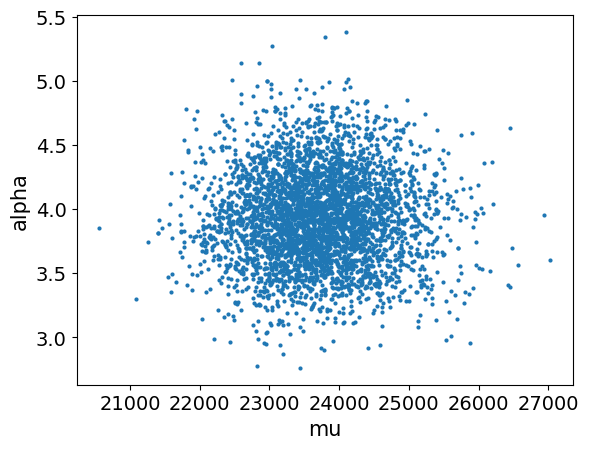

In [12]:
az.plot_pair(samples_1, var_names=variables)

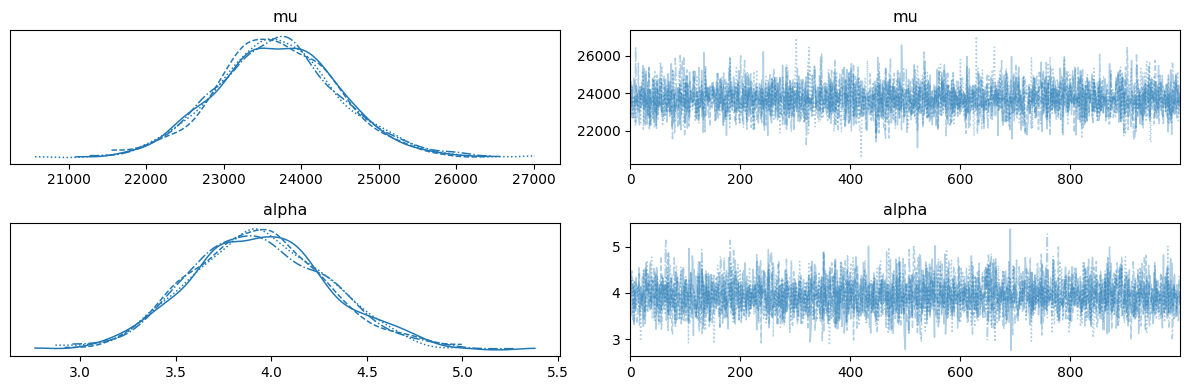

In [13]:
az.plot_trace(samples_1, var_names=variables)
plt.tight_layout()

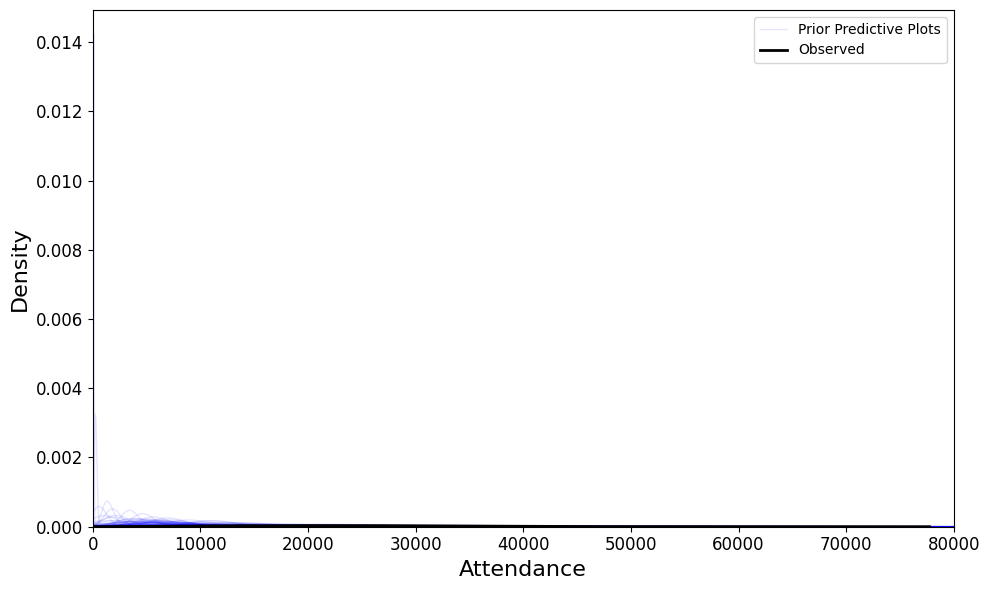

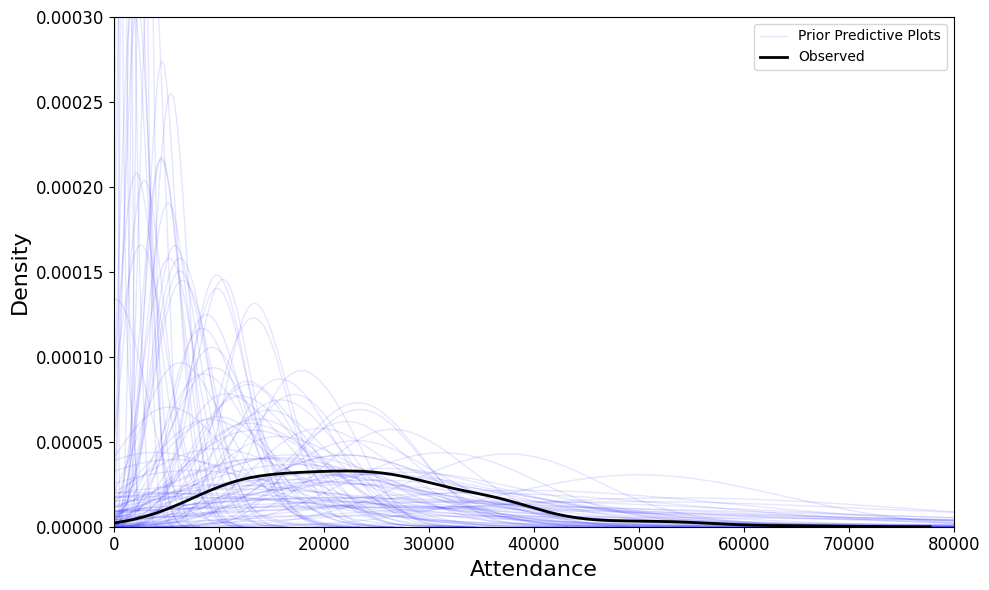

In [14]:
def plot_ppc_m1(data, obs_data, y_lim=None, n_samples=100, random_seed=RANDOM_SEED):
  '''
  creates a prior predictive plot for the model.
  '''
  # simulating the prior predictive
  mu_samples = sts.halfnorm.rvs(scale=20000, size=n_samples)
  alpha_samples = sts.expon.rvs(scale=10, size=n_samples)

  plt.figure(figsize=(10, 6))
  y_plots = []
  # plot samples
  leg = True
  for mu, alpha in zip(mu_samples, alpha_samples):
      # converting the parameters
      n_nb = alpha
      p_nb = n_nb / (n_nb + mu)
      y_sim = sts.nbinom.rvs(n_nb, p_nb, size=100)
      y_plots.append(y_sim)
      if leg:
        sns.kdeplot(y_sim, bw_adjust=2, alpha=0.1, color='blue', linewidth=1, label='Prior Predictive Plots')
        leg = False
      else:
        sns.kdeplot(y_sim, bw_adjust=2, alpha=0.1, color='blue', linewidth=1)

  # plot observed data
  sns.kdeplot(obs_data, color='black', linewidth=2, label='Observed')
  plt.tick_params(axis='x', labelsize=12)
  plt.tick_params(axis='y', labelsize=12)
  plt.xlabel('Attendance', fontsize=16)
  plt.ylabel('Density', fontsize=16)
  plt.xlim(0, 80000)
  if y_lim:
    plt.ylim(0,y_lim)
  plt.legend()
  plt.tight_layout()
  plt.show()

data = pd.read_csv('sports-attendance-data.csv')
obs_data = data['attendance'].dropna()
# plot general plot
plot_ppc_m1(data, obs_data, n_samples=100, random_seed=RANDOM_SEED)

# plot zoomed in
plot_ppc_m1(data, obs_data, y_lim=0.0003, n_samples=100, random_seed=RANDOM_SEED)

Output()

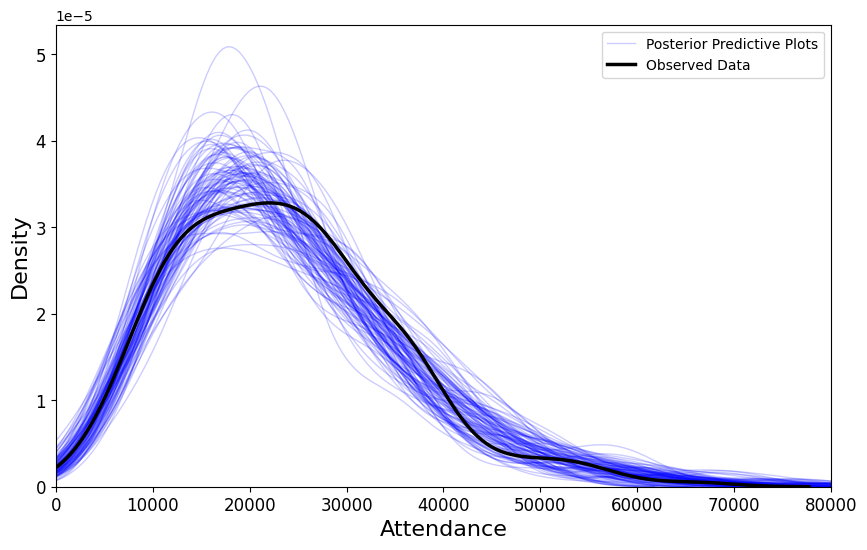

In [15]:
# posterior predictive samples
with model_1:
    pp_samples = pm.sample_posterior_predictive(samples_1, random_seed=RANDOM_SEED)

# attendance values form post. predictive
pp_attendance = pp_samples.posterior_predictive['attendance']
# Combine chains and draws for easier iteration
pp_attendance_flat = pp_attendance.stack(sample=("chain", "draw")).values.T

plt.figure(figsize=(10, 6))
# plot posterior predictive
for i in range(100):
    if i == 0:
      sns.kdeplot(pp_attendance_flat[i],
                bw_adjust=1,
                alpha=0.2,
                color='blue',
                linewidth=1,
                  label="Posterior Predictive Plots")
    else:
      sns.kdeplot(pp_attendance_flat[i],
                bw_adjust=1,
                alpha=0.2,
                color='blue',
                linewidth=1)

# plot observed
sns.kdeplot(data_enc['attendance'].dropna(),
            bw_adjust=1,
            color='black',
            linewidth=2.5,
            label='Observed Data')

plt.xlabel('Attendance', fontsize=16)
plt.ylabel('Density', fontsize=16)
plt.tick_params(axis='x', labelsize=12)
plt.tick_params(axis='y', labelsize=12)
plt.xlim(0, 80000)
plt.legend()
plt.show()

## 3. Model 2: Hierarchical model (partial pooling)

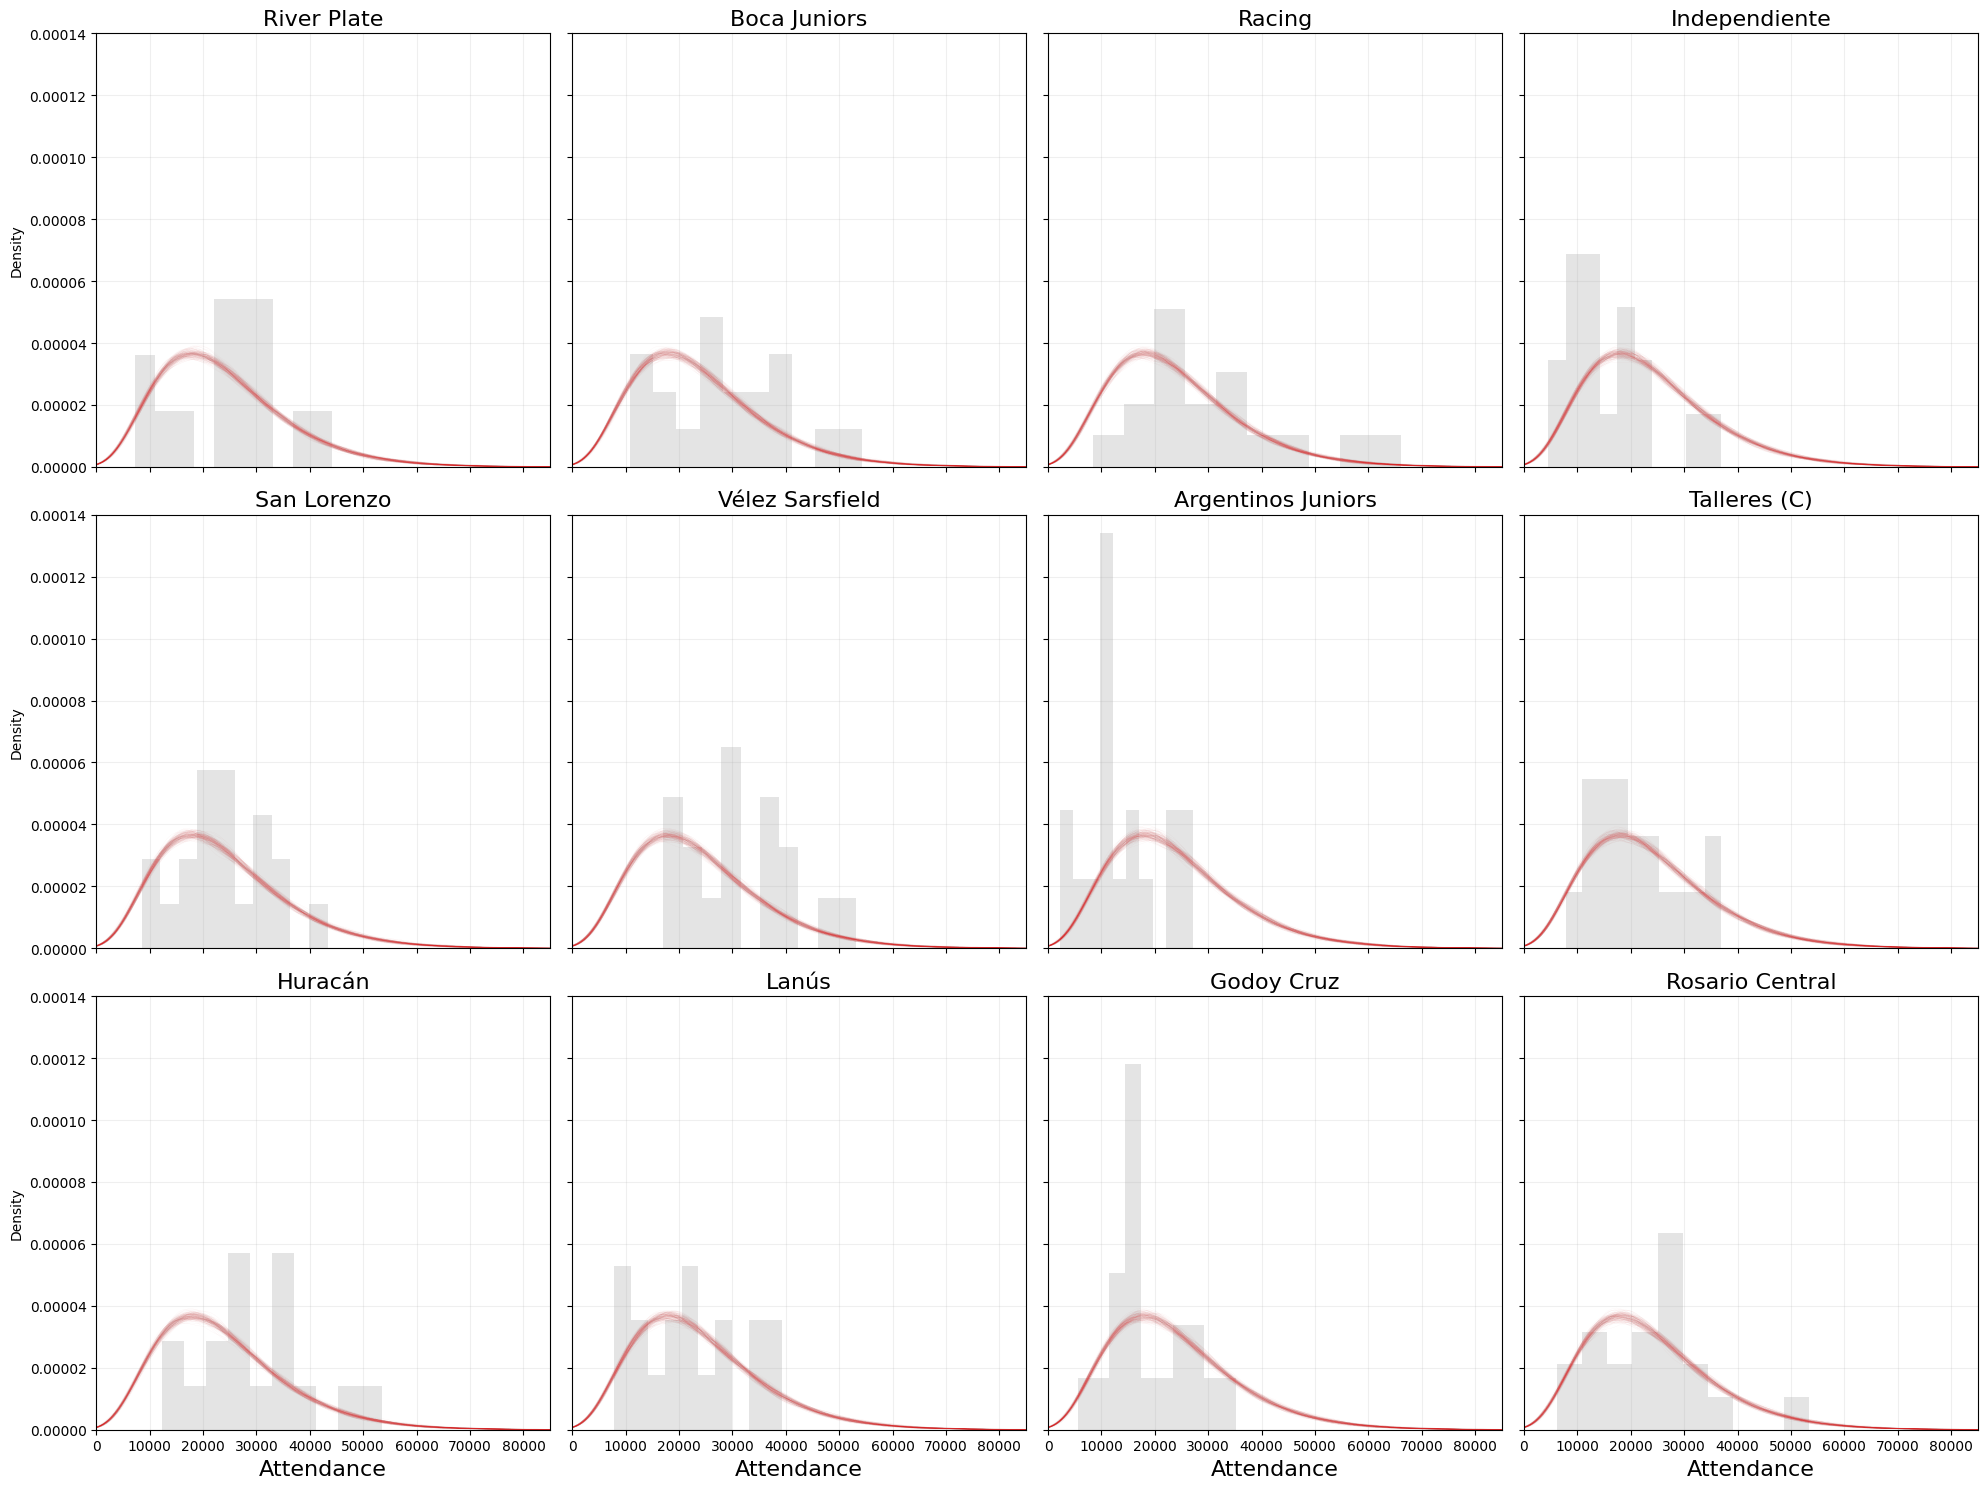

In [16]:
# posterior predictive for model 1 for each team

# getting data and ordering again for robustness
data_obs = data.dropna(subset=['attendance']).copy()
teams = data_obs['team'].unique()
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
team_map = {t: i for i, t in enumerate(teams)}
day_map = {d: i for i, d in enumerate(days_order)}

# extract posterior samples
post = samples_1.posterior
mu_s = post['mu'].values.flatten()
alpha_s = post['alpha'].values.flatten()


# plot
fig, axes = plt.subplots(3, 4, figsize=(20, 15), sharey=True, sharex=True)
axes_flat = axes.flatten()

# for each team
for i, team in enumerate(teams):
    ax = axes_flat[i]
    t_idx = team_map[team]

    # plot the histogram of the observed data
    y_obs = data_obs.loc[data_obs['team'] == team, 'attendance']
    ax.hist(y_obs, density=True, color='lightgray', alpha=0.6, label='Observed (All Days)')

    # for each day
    for d_idx, day in enumerate(days_order):
        for i in range(25): # generate multiple samples

          # attendance distribution for model 1
          n_nb = alpha_s
          p_nb = n_nb / (n_nb + mu_s)
          y_pred = np.random.negative_binomial(n_nb, p_nb)

          # plot curves
          lw = 0.1
          alpha_line = 0.1
          sns.kdeplot(y_pred, ax=ax, color='tab:red', linewidth=lw, alpha=alpha_line,
                      bw_adjust=1, label=day)

    ax.set_title(team, fontsize=16)
    ax.set_ylim(0, 0.00014)
    ax.set_xlim(0, 85000)
    ax.grid(alpha=0.2)

    if i >= 8:
        ax.set_xlabel("Attendance", fontsize=16)
    if i == 0:
        ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

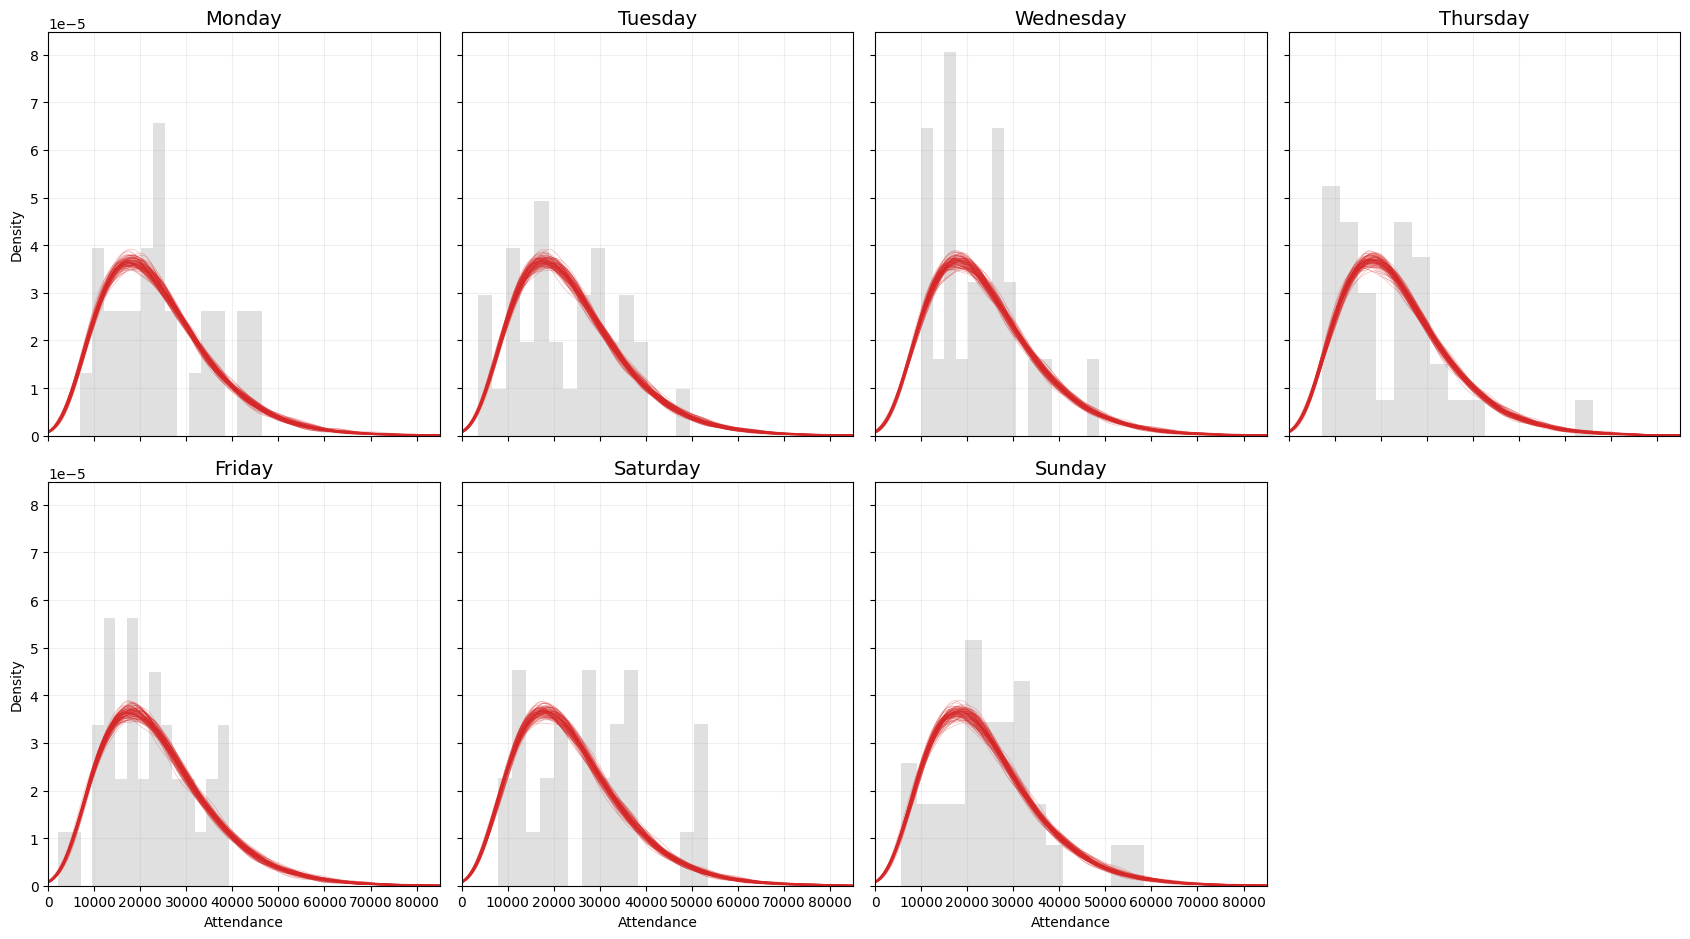

In [17]:
# posterior predictive for model 1 for each day

# getting data and ordering again for robustness
data_obs = data.dropna(subset=['attendance']).copy()
teams = data_obs['team'].unique()
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_map = {d: i for i, d in enumerate(days_order)}


# extract posterior values
post = samples_1.posterior
mu_s = post['mu'].values.flatten()
alpha_s = post['alpha'].values.flatten()

# plot setup
fig, axes = plt.subplots(2, 4, figsize=(20, 10), sharey=True, sharex=True)
axes_flat = axes.flatten()

# for every day
for i, day in enumerate(days_order):
    ax = axes_flat[i]

    # plot histogram of observed data
    y_obs = data_obs.loc[data_obs['day'] == day, 'attendance']
    ax.hist(y_obs, bins=15, density=True, color='lightgray', alpha=0.7, label='Observed (Data)')

    # generate PP 100 samples
    for j in range(100):
        mu_samples = mu_s

        # simulate the neg binomial likelihood
        n_nb = alpha_s
        p_nb = n_nb / (n_nb + mu_samples)
        y_pred = np.random.negative_binomial(n_nb, p_nb)

        # plot
        sns.kdeplot(y_pred, ax=ax, color='tab:red', linewidth=0.5, alpha=0.3,
                    bw_adjust=1, label='Model 1 Prediction' if (i == 0 and j == 0) else "")

    ax.set_title(day, fontsize=14)
    ax.set_xlim(0, 85000)
    ax.grid(alpha=0.2)
    if i >= 4: ax.set_xlabel('Attendance')

# hide empty 8th subplot
axes_flat[-1].set_visible(False)
plt.tight_layout(rect=[0, 0, 0.85, 0.95])
plt.show()

In [18]:
# only the observed days
data_obs = data_enc.dropna(subset=['attendance'])

team_idx = data_obs['team_idx'].values
day_idx = data_obs['day_idx'].values
attendance_obs = data_obs['attendance'].values

with pm.Model() as model_2:
    # hyperpriors
    sigma_team = pm.Exponential('sigma_team', 1)
    sigma_day = pm.Exponential('sigma_day', 1)

    # shape is the number of unique teams/days
    beta = pm.Normal('beta', mu=0, sigma=sigma_team, shape=data_enc['team'].nunique())
    gamma = pm.Normal('gamma', mu=0, sigma=sigma_day, shape=data_enc['day'].nunique())
    intercept = pm.Normal('intercept', mu=10, sigma=1)

    # link function
    mu = pm.math.exp(intercept + beta[team_idx] + gamma[day_idx])
    alpha = pm.Exponential('alpha', 0.1)

    # likelihood
    attendance_mod = pm.NegativeBinomial('attendance', mu=mu, alpha=alpha, observed=attendance_obs)
    samples_2 = pm.sample(chains=4, random_seed = RANDOM_SEED)

Output()

ERROR:pymc.stats.convergence:There were 16 divergences after tuning. Increase `target_accept` or reparameterize.


array([<Axes: title={'center': 'alpha'}, xlabel='Rank (all chains)', ylabel='Chain'>,
       <Axes: title={'center': 'intercept'}, xlabel='Rank (all chains)', ylabel='Chain'>,
       <Axes: title={'center': 'sigma_team'}, xlabel='Rank (all chains)', ylabel='Chain'>,
       <Axes: title={'center': 'sigma_day'}, xlabel='Rank (all chains)', ylabel='Chain'>],
      dtype=object)

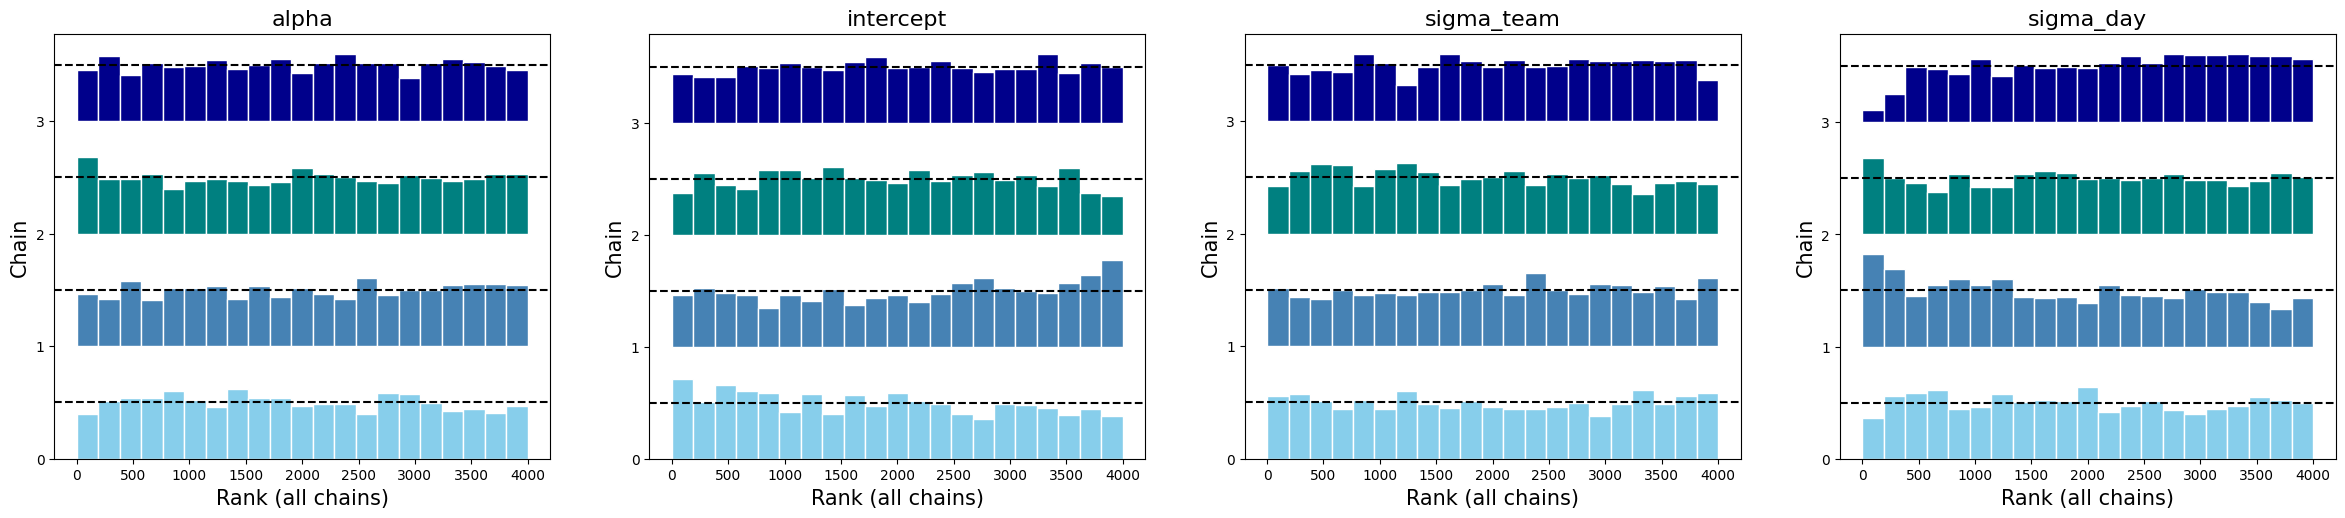

In [19]:
az.plot_rank(samples_2, var_names=['alpha', 'intercept', 'sigma_team', 'sigma_day'], colors=['skyblue', 'steelblue', 'teal', 'darkblue'])

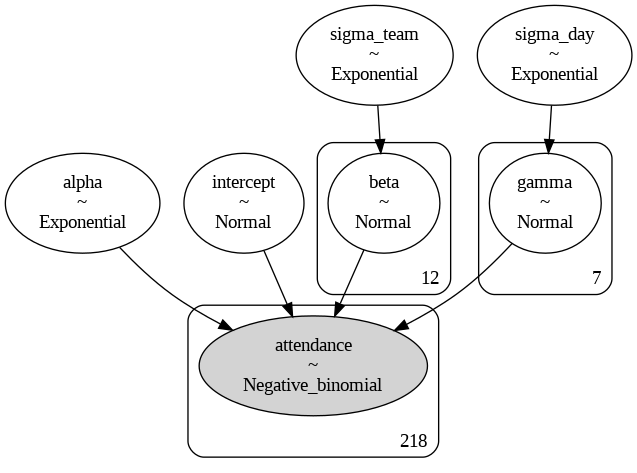

In [20]:
# model structure
pm.model_to_graphviz(model_2)
from IPython.display import Image
Image(pm.model_to_graphviz(model_2).render(format='png'))

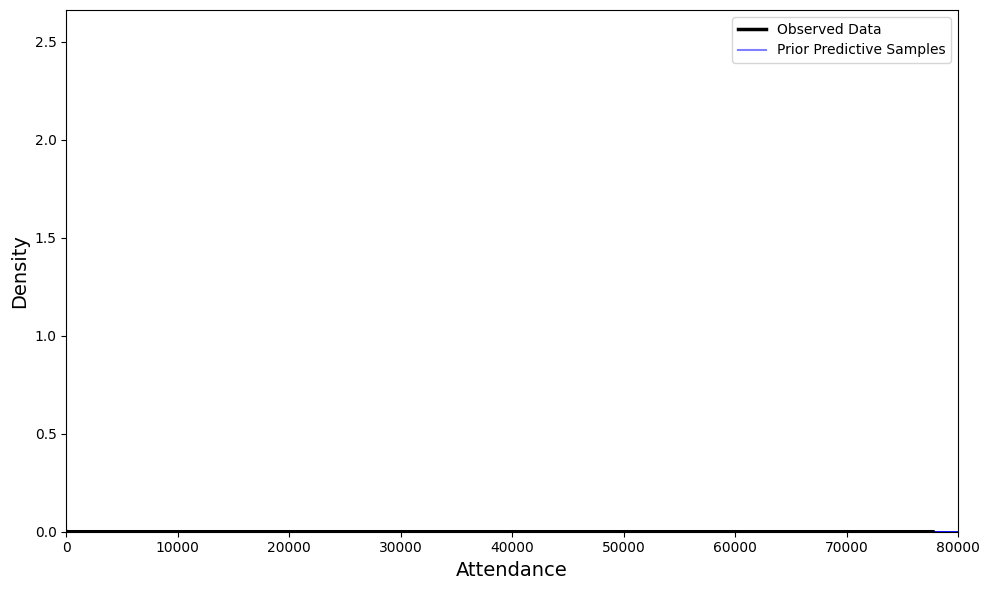

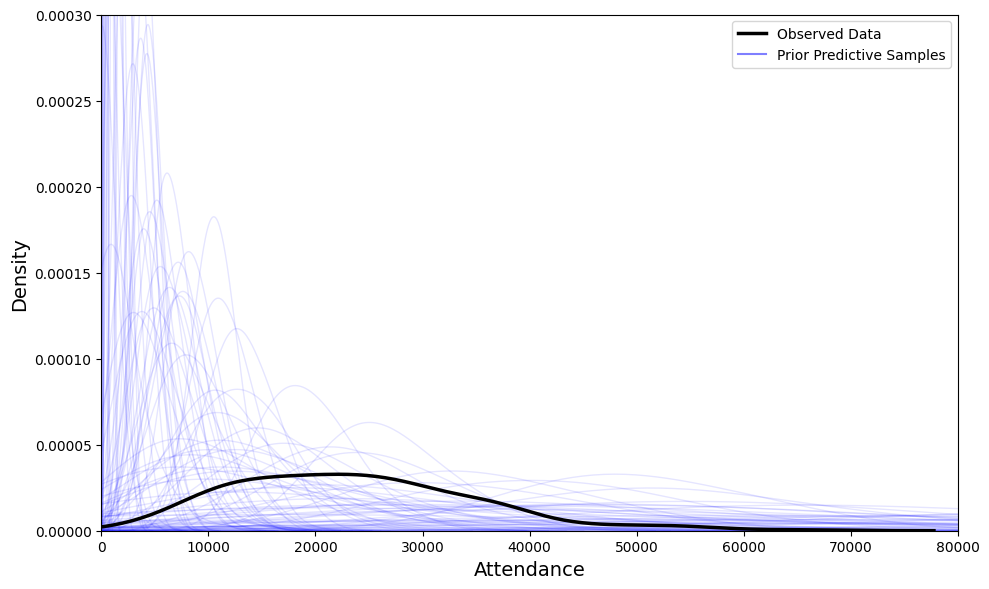

In [21]:
def plot_prior_ppc_m2(obs_data, n_samples=100, y_lim=None):
    '''
    creates a prior predictive plot for the hierarchical model.
    '''
    # get samples from hyperpriors
    sigma_team_samples = sts.expon.rvs(scale=1, size=n_samples)
    sigma_day_samples = sts.expon.rvs(scale=1, size=n_samples)

    # samples for the random effects
    beta_samples = sts.norm.rvs(loc=0, scale=sigma_team_samples, size=n_samples)
    gamma_samples = sts.norm.rvs(loc=0, scale=sigma_day_samples, size=n_samples)

    # samples from the intercept
    intercept_samples = sts.norm.rvs(loc=10, scale=1, size=n_samples)

    # samples from alpha
    # pymc lambda=0.01 corresponds to scipy scale=1/001=10
    alpha_samples = sts.expon.rvs(scale=10, size=n_samples)

    # mu calculation
    mu_samples = np.exp(intercept_samples + beta_samples + gamma_samples)

    plt.figure(figsize=(10, 6))
    for mu, alpha in zip(mu_samples, alpha_samples):
        # convert for scipy nbinom
        n_nb = alpha
        p_nb = n_nb / (n_nb + mu)

        # simulate a dataset
        y_sim = sts.nbinom.rvs(n_nb, p_nb, size=len(obs_data))
        sns.kdeplot(y_sim, bw_adjust=2, alpha=0.1, color='blue', linewidth=1)

    # observed data
    sns.kdeplot(obs_data, color='black', linewidth=2.5, label='Observed Data')

    # legend label & plotting
    plt.plot([], [], color='blue', alpha=0.5, label='Prior Predictive Samples')
    plt.xlabel('Attendance', fontsize=14)
    plt.ylabel('Density', fontsize=14)
    plt.xlim(0, 80000)
    if y_lim:
        plt.ylim(0, y_lim)
    plt.legend()
    plt.tight_layout()
    plt.show()


data = pd.read_csv('sports-attendance-data.csv')
obs_data = data['attendance'].dropna()

# overview
plot_prior_ppc_m2(obs_data, n_samples=100)

# zoomed in view
plot_prior_ppc_m2(obs_data, n_samples=100, y_lim=0.0003)

In [22]:
az.summary(samples_2)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,4.995,0.484,4.093,5.920,0.007,0.008,4266.0,2344.0,1.00
beta[0],0.075,0.125,-0.164,0.300,0.003,0.002,1755.0,2339.0,1.00
beta[1],0.189,0.124,-0.046,0.428,0.003,0.002,1336.0,1669.0,1.00
beta[2],0.241,0.124,0.024,0.492,0.003,0.002,1579.0,1522.0,1.00
beta[3],-0.305,0.123,-0.536,-0.073,0.003,0.002,1644.0,2285.0,1.00
beta[4],0.034,0.118,-0.182,0.261,0.003,0.002,1648.0,1795.0,1.00
beta[5],0.250,0.125,0.028,0.493,0.003,0.002,1474.0,1878.0,1.00
beta[6],-0.434,0.128,-0.666,-0.191,0.003,0.002,1602.0,2221.0,1.00
beta[7],-0.097,0.123,-0.325,0.129,0.003,0.002,1499.0,2005.0,1.00
beta[8],0.218,0.127,-0.024,0.449,0.003,0.002,1357.0,1685.0,1.00


In [23]:
# REPARAMETERIZATION
# only the observed days
data_obs = data_enc.dropna(subset=['attendance'])

team_idx = data_obs['team_idx'].values
day_idx = data_obs['day_idx'].values
attendance_obs = data_obs['attendance'].values

with pm.Model() as model_2_rep:
    # hyperpriors
    sigma_team = pm.Exponential('sigma_team', 1) # >0
    sigma_day = pm.Exponential('sigma_day', 1) # >0

    # shape is the number of unique teams/days
    beta_rep = pm.Normal('beta_rep', mu=0, sigma=1, shape=data_enc['team'].nunique())
    beta = pm.Deterministic('beta', beta_rep * sigma_team) # adaptive prior 1

    gamma_rep = pm.Normal('gamma_rep', mu=0, sigma=1, shape=data_enc['day'].nunique())
    gamma = pm.Deterministic('gamma', gamma_rep * sigma_day) # adaptive prior 2

    intercept = pm.Normal('intercept', mu=10, sigma=1) # random effects

    # link function
    mu = pm.math.exp(intercept + beta[team_idx] + gamma[day_idx])
    alpha = pm.Exponential('alpha', 0.01)

    # likelihood
    attendance_mod = pm.NegativeBinomial('attendance', mu=mu, alpha=alpha, observed=attendance_obs)
    samples_2_2 = pm.sample(chains=4, random_seed = RANDOM_SEED)

Output()

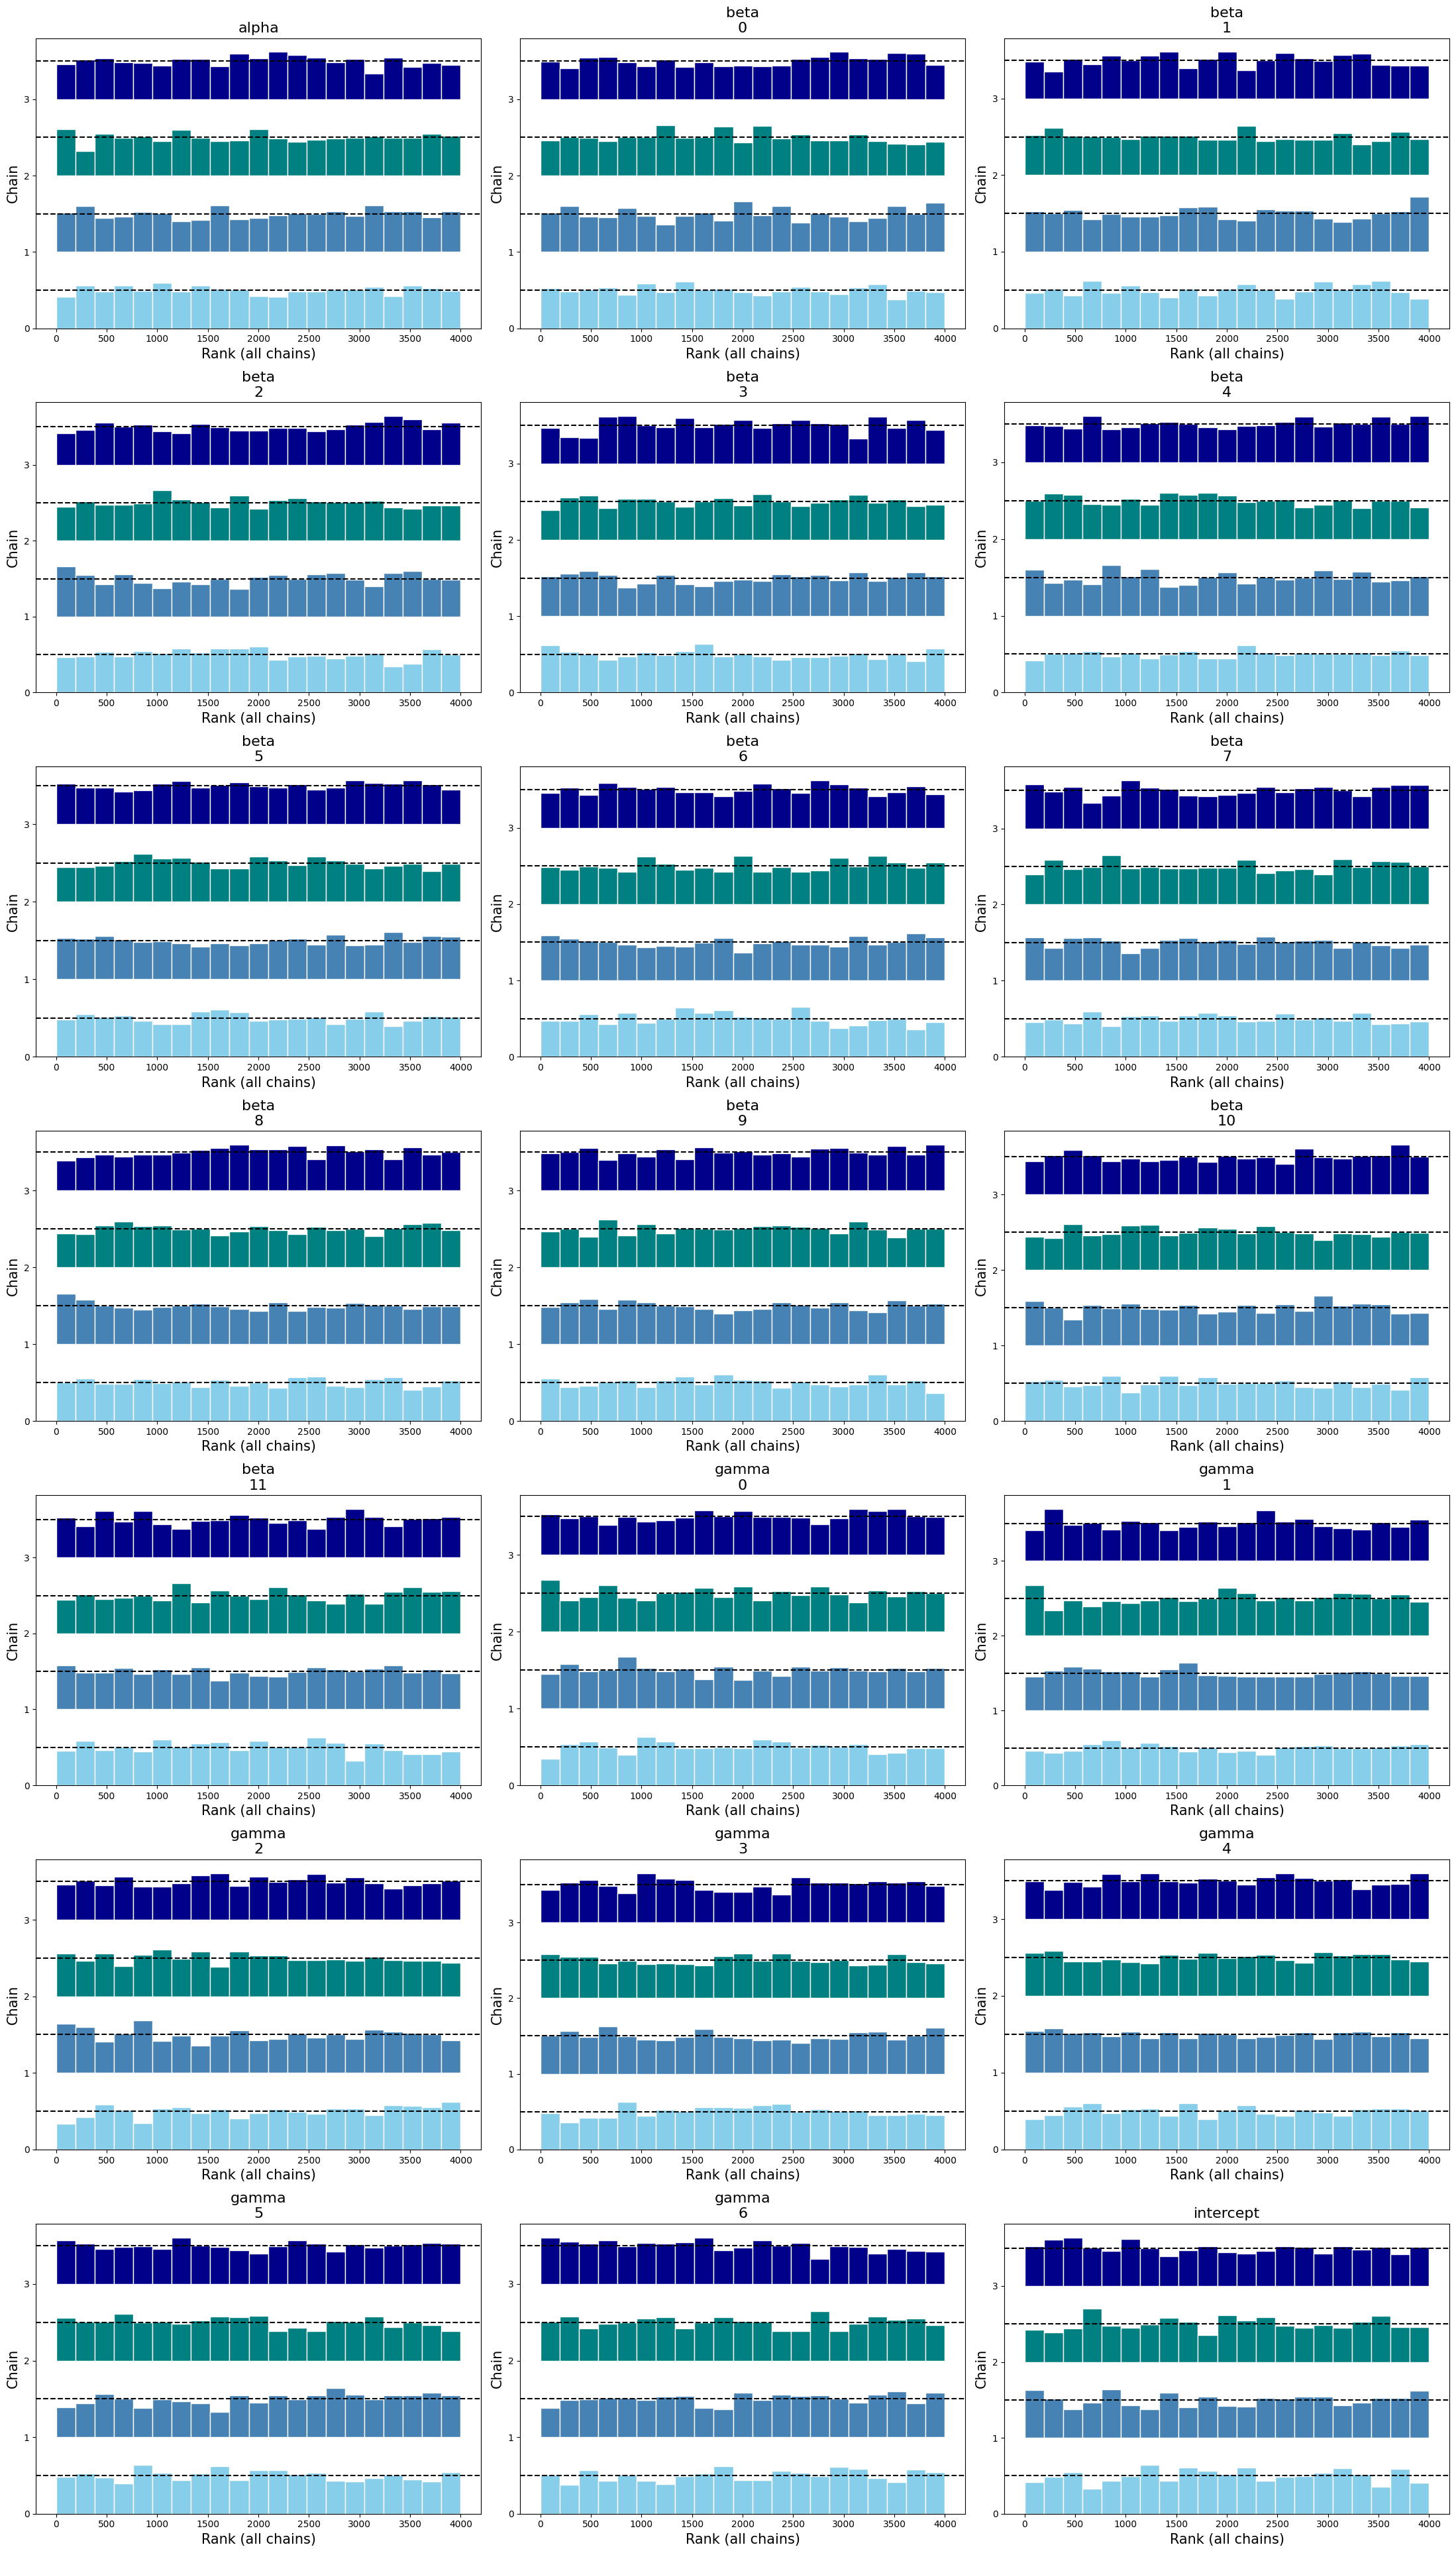

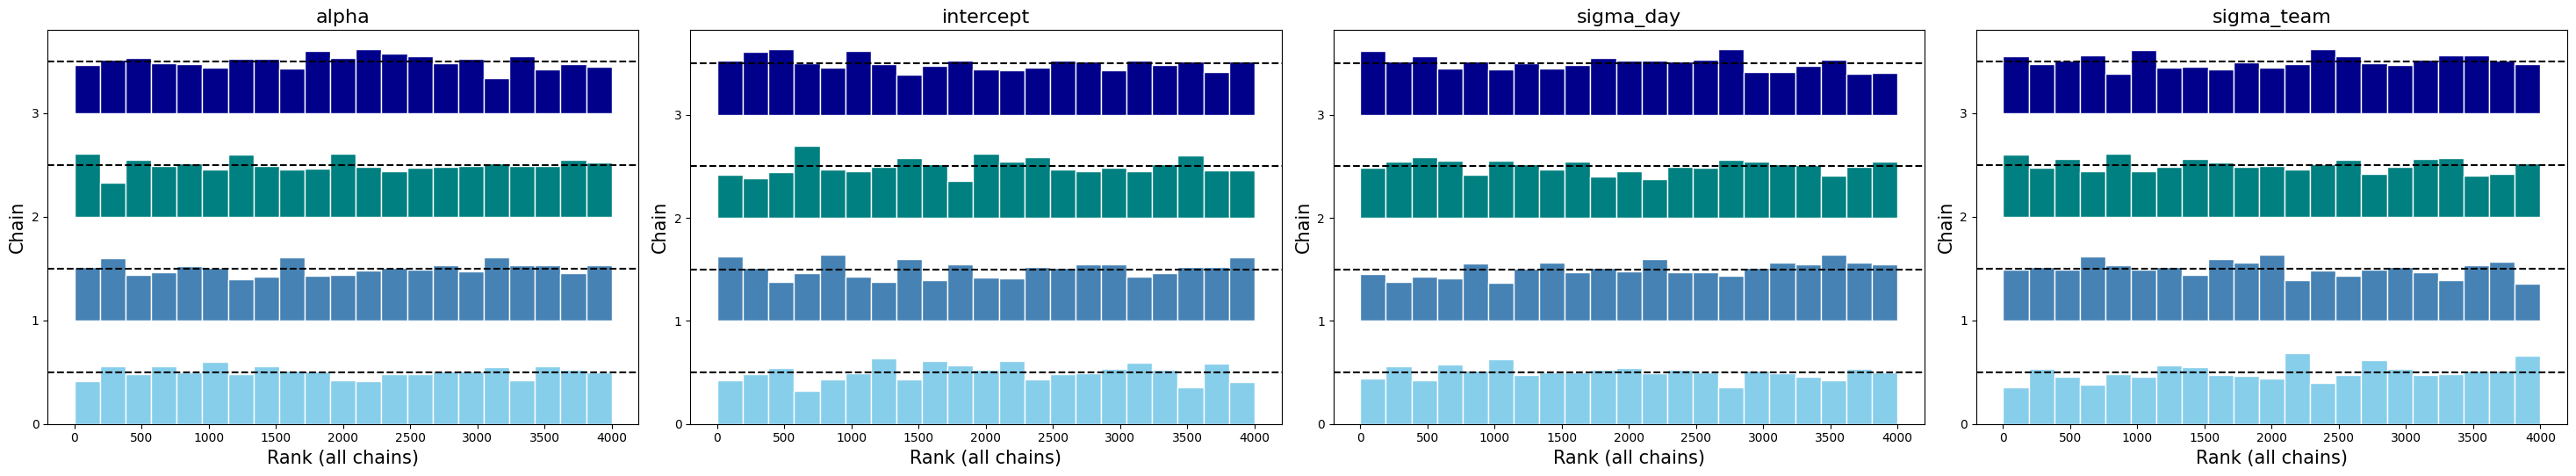

In [24]:
az.plot_rank(samples_2_2, ref_line=True, var_names=['alpha', 'beta', 'gamma', 'intercept'], colors=['skyblue', 'steelblue', 'teal', 'darkblue'])
plt.tight_layout()
plt.show()
az.plot_rank(samples_2_2, ref_line=True, var_names=['alpha', 'intercept', 'sigma_day', 'sigma_team'], colors=['skyblue', 'steelblue', 'teal', 'darkblue'])
plt.tight_layout()
plt.show()

array([[<Axes: title={'center': 'alpha'}>,
        <Axes: title={'center': 'alpha'}>],
       [<Axes: title={'center': 'beta'}>,
        <Axes: title={'center': 'beta'}>],
       [<Axes: title={'center': 'beta_rep'}>,
        <Axes: title={'center': 'beta_rep'}>],
       [<Axes: title={'center': 'gamma'}>,
        <Axes: title={'center': 'gamma'}>],
       [<Axes: title={'center': 'gamma_rep'}>,
        <Axes: title={'center': 'gamma_rep'}>],
       [<Axes: title={'center': 'intercept'}>,
        <Axes: title={'center': 'intercept'}>],
       [<Axes: title={'center': 'sigma_day'}>,
        <Axes: title={'center': 'sigma_day'}>],
       [<Axes: title={'center': 'sigma_team'}>,
        <Axes: title={'center': 'sigma_team'}>]], dtype=object)

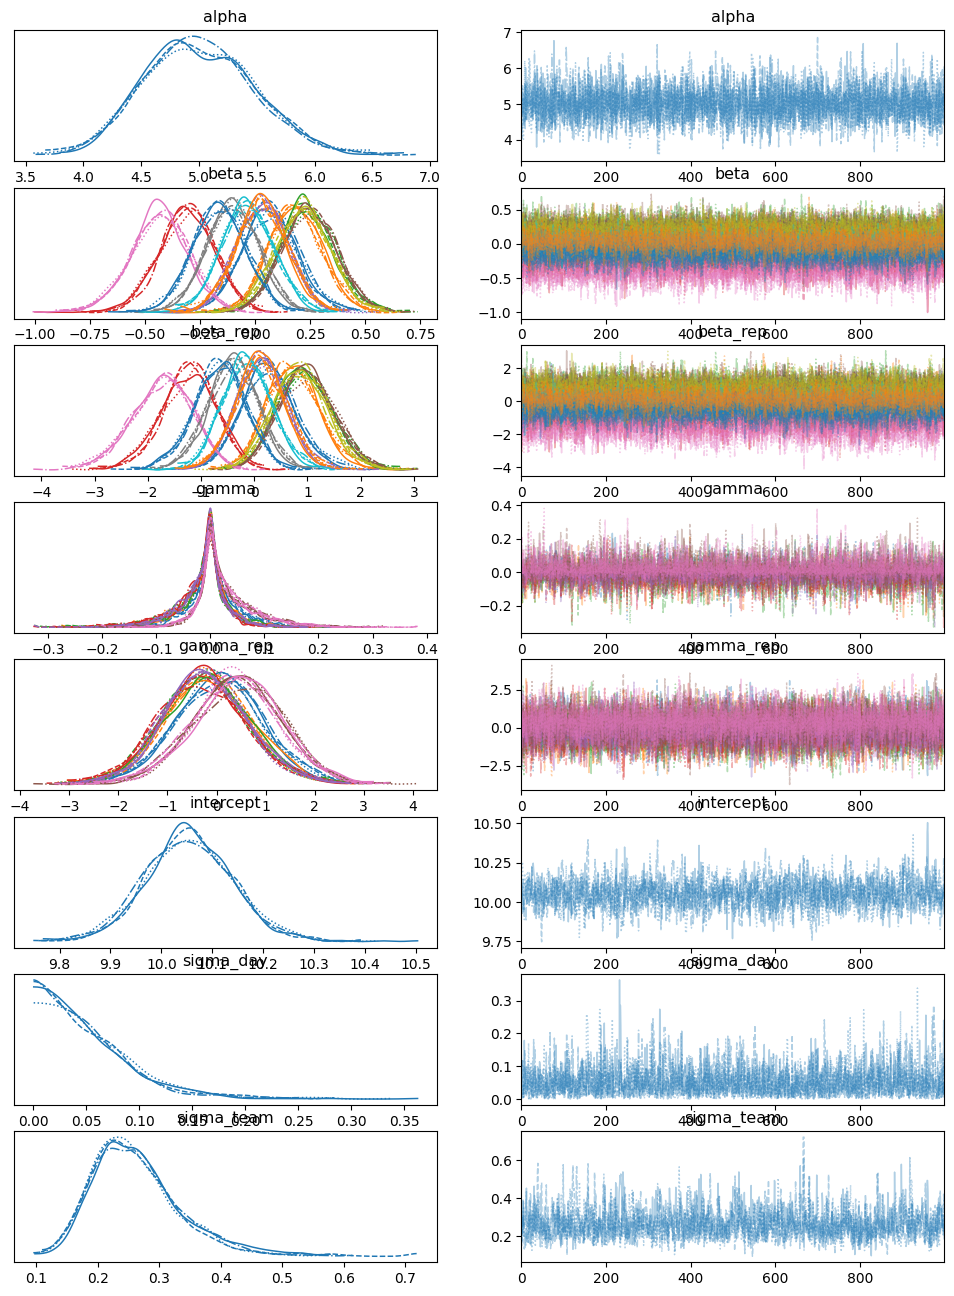

In [25]:
az.plot_trace(samples_2_2)

Output()

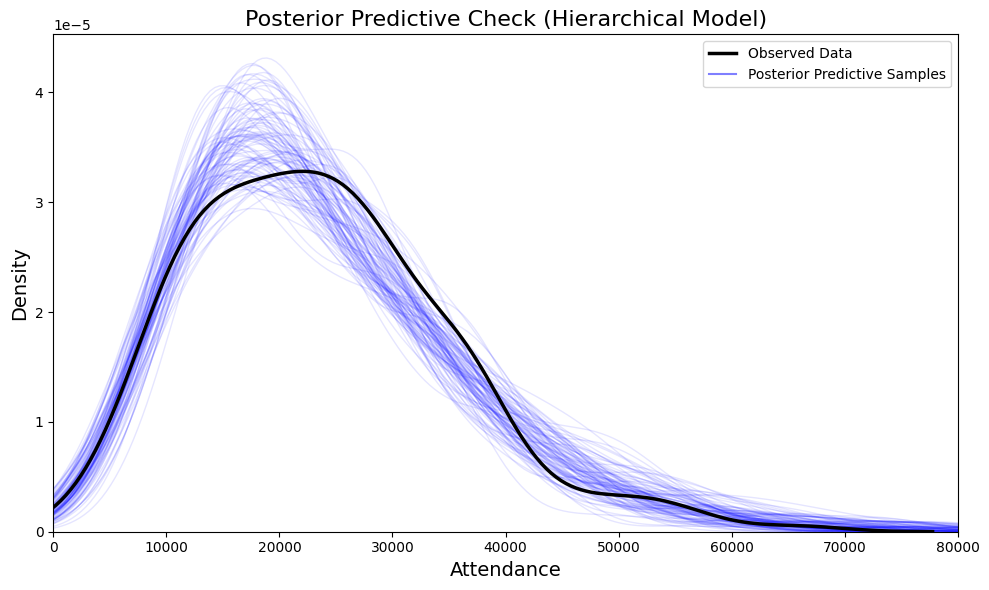

In [26]:
def plot_posterior_ppc_m2(model, trace, obs_data, n_samples=50):
    '''
    creates a posterior predictive plot using the trained PyMC model trace.
    '''
    # posterior predictive samples
    with model:
        pp_samples = pm.sample_posterior_predictive(trace, random_seed=RANDOM_SEED)

    # flatten data
    pp_data = pp_samples.posterior_predictive['attendance'].stack(sample=("chain", "draw")).values.T
    plt.figure(figsize=(10, 6))

    # get n_samples random samples and plot them
    indices = np.random.choice(pp_data.shape[0], n_samples, replace=False)
    for i in indices:
        sns.kdeplot(pp_data[i], bw_adjust=1, alpha=0.1, color='blue', linewidth=1)

    # plot observed
    sns.kdeplot(obs_data, bw_adjust=1, color='black', linewidth=2.5, label='Observed Data')

    # add legend to posterior samples
    plt.plot([], [], color='blue', alpha=0.5, label='Posterior Predictive Samples')

    # plot
    plt.title('Posterior Predictive Check (Hierarchical Model)', fontsize=16)
    plt.xlabel('Attendance', fontsize=14)
    plt.ylabel('Density', fontsize=14)
    plt.xlim(0, 80000)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_posterior_ppc_m2(model_2_rep, samples_2_2, obs_data, n_samples=100)

/tmp/ipython-input-3870032259.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('viridis', len(days_order))


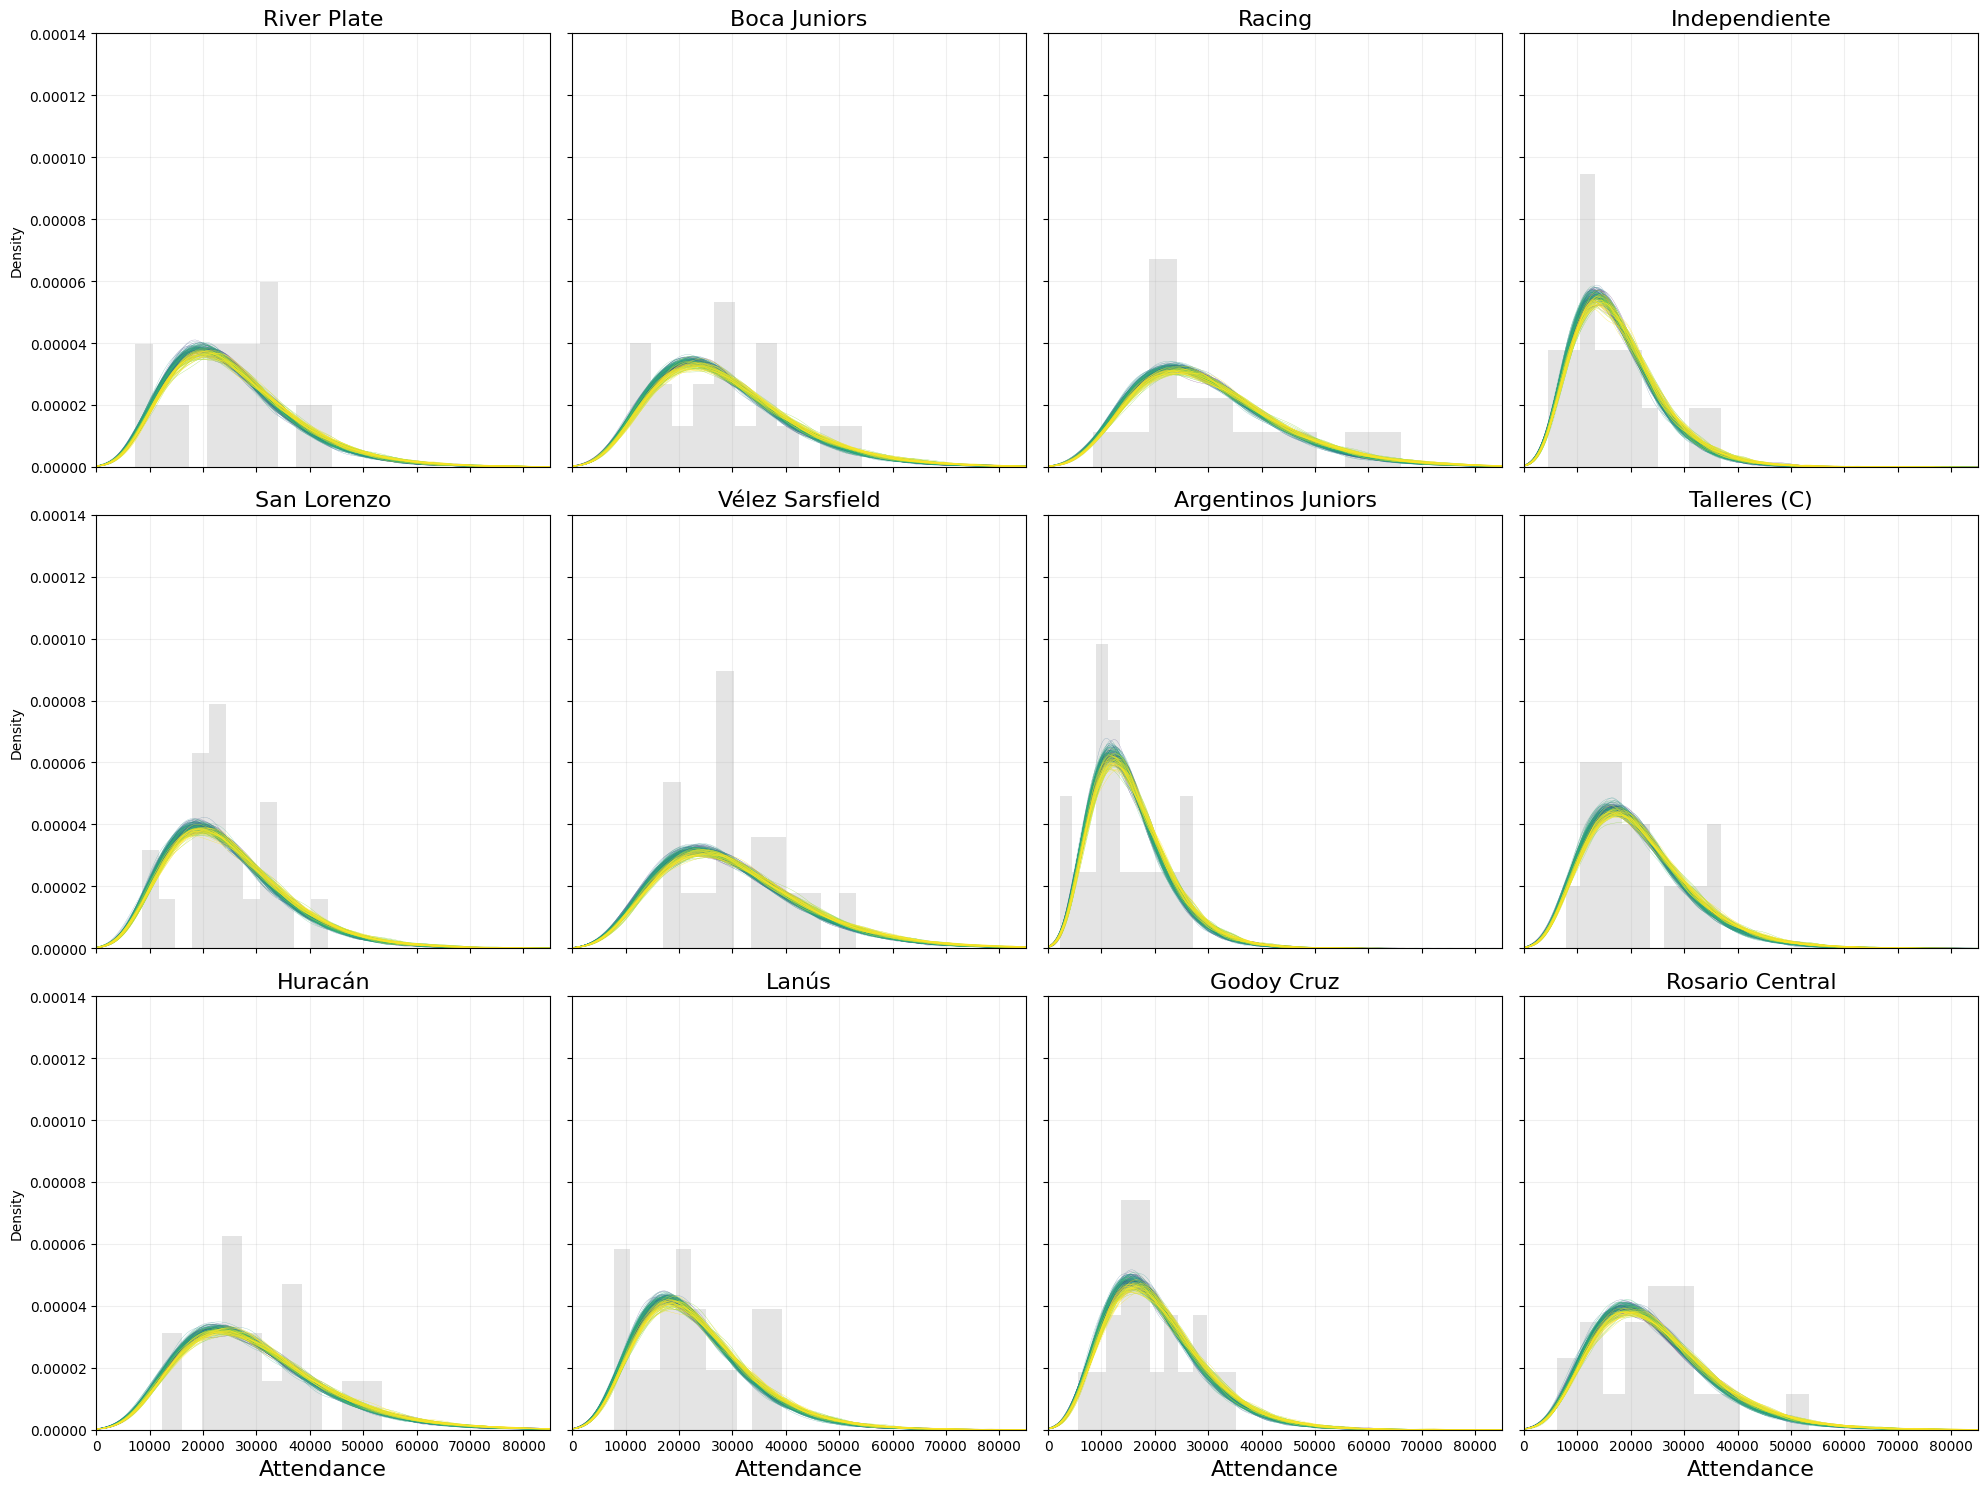

In [27]:
# posterior predictive for model 2 for each team

# getting data and ordering again for robustness
data_obs = data.dropna(subset=['attendance']).copy()
teams = data_obs['team'].unique()
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
team_map = {t: i for i, t in enumerate(teams)}
day_map = {d: i for i, d in enumerate(days_order)}

# extract posterior samples
post = samples_2_2.posterior
intercept_s = post['intercept'].values.flatten()
alpha_s = post['alpha'].values.flatten()
beta_s = post['beta'].values.reshape(len(intercept_s), -1)
gamma_s = post['gamma'].values.reshape(len(intercept_s), -1)

# color each weekday differently
colors = cm.get_cmap('viridis', len(days_order))

# plottig setup
fig, axes = plt.subplots(3, 4, figsize=(20, 15), sharey=True, sharex=True)
axes_flat = axes.flatten()

# for each of the teams
for i, team in enumerate(teams):
    ax = axes_flat[i]
    t_idx = team_map[team]

    # plot the histogram of the observed data
    y_obs = data_obs.loc[data_obs['team'] == team, 'attendance']
    ax.hist(y_obs, bins=11, density=True, color='lightgray', alpha=0.6, label='Observed (All Days)')

    # plot posterior predictive samples for each day
    for d_idx, day in enumerate(days_order):
        for j in range(25): # generate multiple lines per weekday
          # calculate mu for this specific team/day combination
          mu_samples = np.exp(intercept_s + beta_s[:, t_idx] + gamma_s[:, d_idx])

          # attendance distribution
          n_nb = alpha_s
          p_nb = n_nb / (n_nb + mu_samples)
          y_pred = np.random.negative_binomial(n_nb, p_nb)

          # plot curves
          lw = 0.2
          alpha_line = 0.9 if day in ['Saturday', 'Sunday'] else 0.6
          sns.kdeplot(y_pred, ax=ax, color=colors(d_idx), linewidth=lw, alpha=alpha_line,
                      bw_adjust=1, label=day)

    ax.set_title(team, fontsize=16)
    ax.set_ylim(0, 0.00014)
    ax.set_xlim(0, 85000)

    # for these small dense plots i use a grid
    ax.grid(alpha=0.2)

    if i >= 8:
        ax.set_xlabel("Attendance", fontsize=16)

plt.tight_layout()
plt.show()

/tmp/ipython-input-2977450357.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('viridis', len(teams))


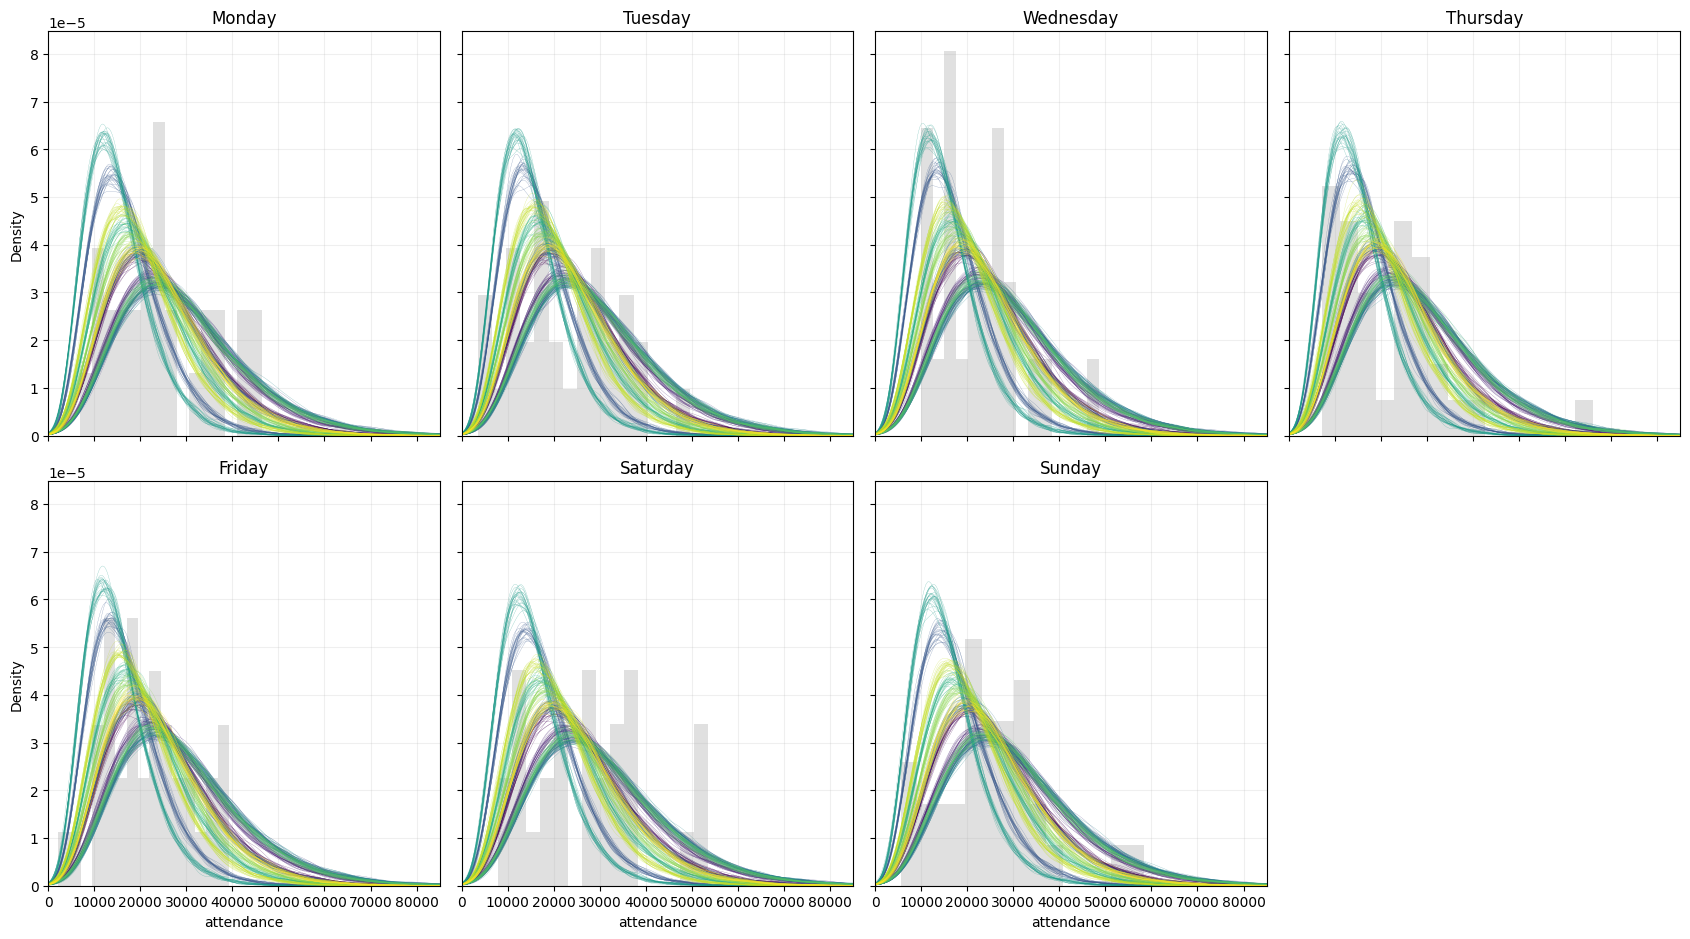

In [28]:
# posterior predictive for model 2 for each day

# getting data and ordering again for robustness
data_obs = data.dropna(subset=['attendance']).copy()
teams = data_obs['team'].unique()
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
team_map = {t: i for i, t in enumerate(teams)}
day_map = {d: i for i, d in enumerate(days_order)}

# posterior samples
post = samples_2_2.posterior
intercept_s = post['intercept'].values.flatten()
alpha_s = post['alpha'].values.flatten()
beta_s = post['beta'].values.reshape(len(intercept_s), -1)
gamma_s = post['gamma'].values.reshape(len(intercept_s), -1)

# colors for 12 teams
colors = cm.get_cmap('viridis', len(teams))

# plot
fig, axes = plt.subplots(2, 4, figsize=(20, 10), sharey=True, sharex=True)
axes_flat = axes.flatten()

# loop through days (subplots)
for i, day in enumerate(days_order):
    ax = axes_flat[i]
    d_idx = day_map[day]

    # plot observed histogram for this day (all teams)
    y_obs = data_obs.loc[data_obs['day'] == day, 'attendance']
    ax.hist(y_obs, bins=15, density=True, color='lightgray', alpha=0.7, label='observed (all teams)')

    # plot predictive curves for each team
    for t_idx, team in enumerate(teams):
        for j in range(25): # generate multiple lines per team
          # calculate mu for team + day
          mu_samples = np.exp(intercept_s + beta_s[:, t_idx] + gamma_s[:, d_idx])

          # simulate negative binomial
          n_nb = alpha_s
          p_nb = n_nb / (n_nb + mu_samples)
          y_pred = np.random.negative_binomial(n_nb, p_nb)

          # plot curve
          sns.kdeplot(y_pred, ax=ax, color=colors(t_idx), linewidth=0.2, alpha=0.6,
                      bw_adjust=1, label=team if i == 0 else "")

    ax.set_title(day)
    ax.set_xlim(0, 85000)
    ax.grid(alpha=0.2)
    if i >= 4: ax.set_xlabel('attendance')

# hide empty 8th subplot
axes_flat[-1].set_visible(False)

# global legend
plt.tight_layout(rect=[0, 0, 0.85, 0.95])
plt.show()

In [29]:
az.summary(samples_2_2)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,5.006,0.474,4.152,5.870,0.006,0.008,5526.0,3060.0,1.0
beta[0],0.068,0.129,-0.166,0.316,0.003,0.002,2570.0,2508.0,1.0
beta[1],0.183,0.122,-0.022,0.432,0.002,0.002,2411.0,2760.0,1.0
beta[2],0.239,0.126,-0.014,0.462,0.003,0.002,2361.0,2446.0,1.0
beta[3],-0.309,0.126,-0.543,-0.077,0.003,0.002,2296.0,2903.0,1.0
beta[4],0.034,0.118,-0.190,0.245,0.002,0.002,2293.0,2647.0,1.0
beta[5],0.247,0.125,0.022,0.485,0.002,0.002,2523.0,3167.0,1.0
beta[6],-0.435,0.132,-0.688,-0.187,0.003,0.002,2285.0,2877.0,1.0
beta[7],-0.101,0.120,-0.328,0.121,0.002,0.002,2325.0,2553.0,1.0
beta[8],0.217,0.126,-0.038,0.428,0.003,0.002,2293.0,3075.0,1.0


<Figure size 1000x1200 with 0 Axes>

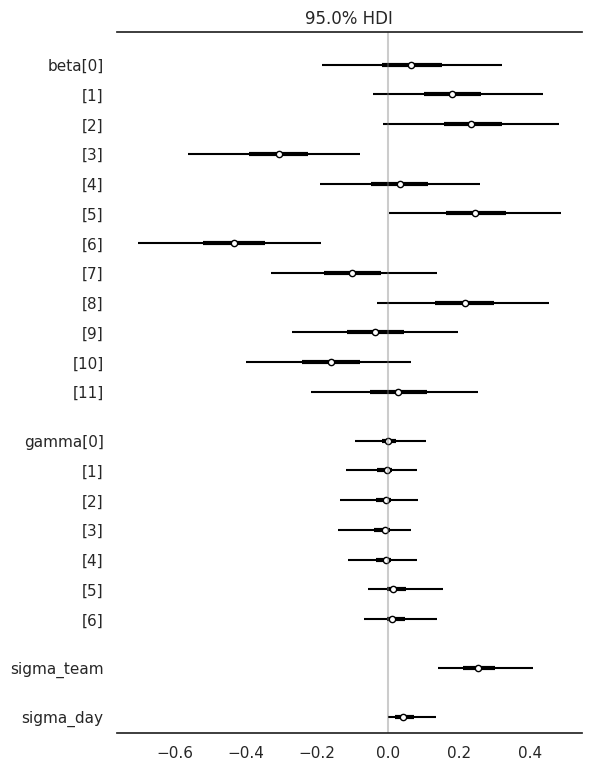

In [30]:
# intial posterior plot exploration
sns.set_theme(style="white", palette=None)

# posterior of team and day
plt.figure(figsize=(10, 12))
az.plot_forest(samples_2_2, kind='forestplot', var_names=['beta', 'gamma', 'sigma_team', 'sigma_day'], colors='black', legend=True, hdi_prob =0.95, combined=True)
plt.axvline(0, color='grey', linestyle='-', alpha=0.4)
plt.show()

Text(0, 0.5, 'Density')

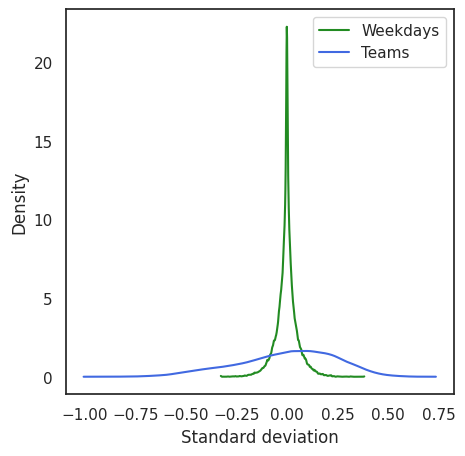

In [31]:
# adapted from class session 17
_, ax = plt.subplots(1, 1, figsize=(5, 5))

az.plot_kde(samples_2_2.posterior.gamma.values, ax=ax, plot_kwargs={"color": "forestgreen"}, label='Weekdays')
az.plot_kde(samples_2_2.posterior.beta.values, ax=ax, plot_kwargs={"color": "royalblue"}, label='Teams')

#ax.text(2, 0.75, "actor", color="black")
#ax.text(0.5, 2, "block", color="blue")
ax.set_xlabel("Standard deviation")
ax.set_ylabel("Density")
#ax.set_xlim(-0.1, 4.1);

## 4. Model Comparison

In [32]:
# log likelihood
with model_1:
  pm.compute_log_likelihood(samples_1)

with model_2:
  pm.compute_log_likelihood(samples_2)

with model_2_rep:
  pm.compute_log_likelihood(samples_2_2)


Output()

Output()

Output()

                  rank     elpd_loo      p_loo  elpd_diff  weight         se  \
Partial Pooling      0 -2316.825409  12.567463   0.000000     1.0  10.320541   
Complete Pooling     1 -2335.049570   1.887400  18.224161     0.0  10.144371   

                       dse  warning scale  
Partial Pooling   0.000000    False   log  
Complete Pooling  5.582008    False   log  


<Axes: xlabel='elpd_loo (log)', ylabel='ranked models'>

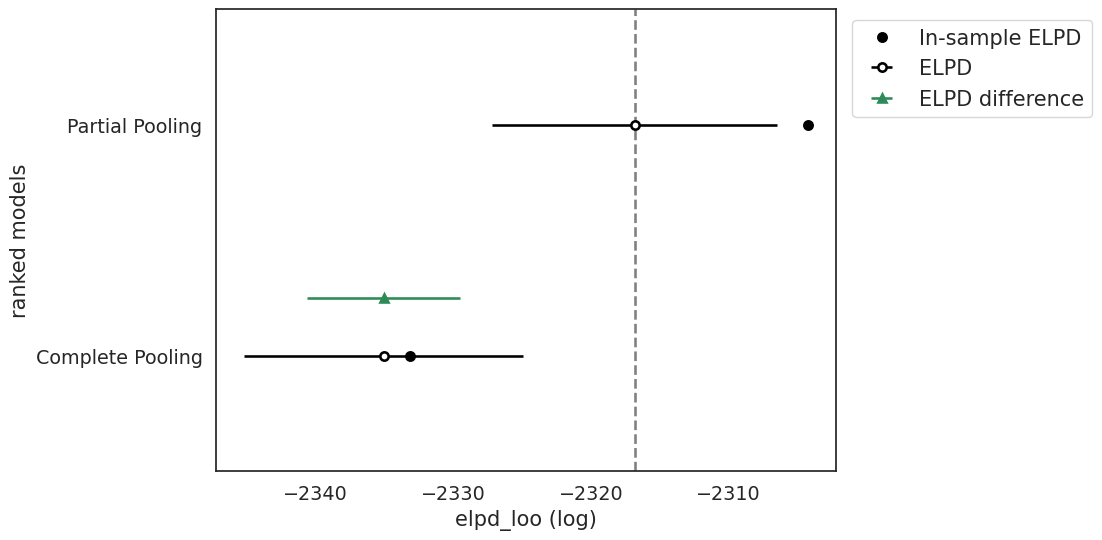

In [33]:
# model comparison
psis_comp_fin = az.compare({'Complete Pooling': samples_1, 'Partial Pooling': samples_2_2}, ic='loo')
print(psis_comp_fin)
az.plot_compare(psis_comp_fin,plot_ic_diff=True, insample_dev=True, title=False, plot_kwargs = {'color_dse': "seagreen"}, figsize=(8,6), legend=True)

In [34]:
# PREDICTION

# enforce a strict ordering on days and teams
teams = data_enc['team'].unique()
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
team_map = {t: i for i, t in enumerate(teams)}
day_map = {d: i for i, d in enumerate(days_order)}

# get all the missing games
missing_games = data[data['attendance'].isna()].copy()

# lists to store the information (encoded and real names)
games_dict = []
enc_games_dict = []

# iterate through the rows with nan data and extract team and day
for index, row_data in missing_games.iterrows():
    team_name = row_data['team']
    day_name = row_data['day']
    games_dict.append((team_name, day_name))
    enc_games_dict.append((team_map[team_name], day_map[day_name]))

# predicting each missing datapoint
for dd, tt in games_dict:
  d_idx = day_map[tt]
  t_idx = team_map[dd]
  # flattening the posterior values
  posterior = samples_2_2.posterior.stack(sample=('chain', 'draw')).transpose('sample', ...)

  # picking posterior values for a specific team and day (4000 samples each)
  intercept_samples = posterior['intercept'].values
  alpha_samples = posterior['alpha'].values
  beta_samples = posterior['beta'].values[:, t_idx]
  gamma_samples = posterior['gamma'].values[:, d_idx]

  # calculating mu deterministically
  mu_samples = np.exp(intercept_samples + beta_samples + gamma_samples)

  # simulate posterior predictive using scipy
  # necessary conversion from alpha and mu to n and p:
    # n = alpha
    # p = n / (n + mu)
  n_nb = alpha_samples
  p_nb = n_nb / (n_nb + mu_samples)
  pred_attendance = np.random.negative_binomial(n_nb, p_nb)
  mean_val = np.mean(pred_attendance)
  hdi_val = np.percentile(pred_attendance, [2.5, 97.5])

  print(f"{dd} on {tt}:")
  print(f'\tMean Attendance = {mean_val:.0f}')
  print(f'\t95% Interval    = {hdi_val[0]:.0f} to {hdi_val[1]:.0f}\n')

River Plate on Thursday:
	Mean Attendance = 24581
	95% Interval    = 7053 to 51220

River Plate on Tuesday:
	Mean Attendance = 24954
	95% Interval    = 7594 to 53997

River Plate on Friday:
	Mean Attendance = 24670
	95% Interval    = 7684 to 52203

River Plate on Monday:
	Mean Attendance = 25322
	95% Interval    = 8131 to 52161

River Plate on Tuesday:
	Mean Attendance = 24730
	95% Interval    = 7557 to 51829

Boca Juniors on Wednesday:
	Mean Attendance = 27627
	95% Interval    = 8627 to 58549

Racing on Tuesday:
	Mean Attendance = 29292
	95% Interval    = 9046 to 61312

Racing on Sunday:
	Mean Attendance = 30084
	95% Interval    = 9731 to 62364

Racing on Tuesday:
	Mean Attendance = 29451
	95% Interval    = 8757 to 62255

Independiente on Tuesday:
	Mean Attendance = 17190
	95% Interval    = 5375 to 36444

Independiente on Thursday:
	Mean Attendance = 16896
	95% Interval    = 5387 to 35237

Vélez Sarsfield on Wednesday:
	Mean Attendance = 29656
	95% Interval    = 9381 to 62107

Vélez S

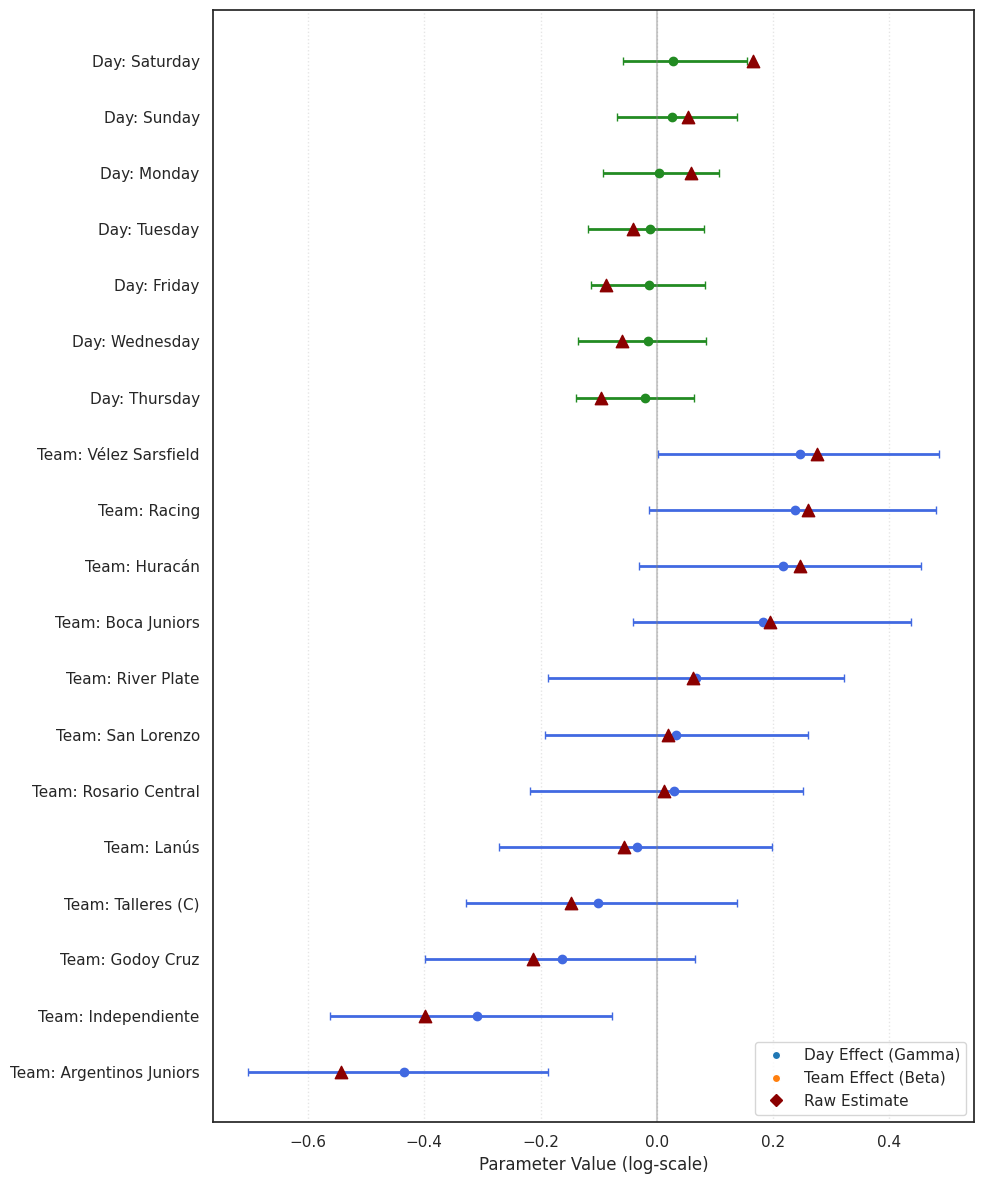

In [35]:
# posterior and shrinkage plot

# enforce data ordering
teams = data['team'].unique()
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# calculating the global estimates of the team effects
global_mean_log = np.log(data_obs['attendance'].mean())
raw_team_means = data_obs.groupby('team')['attendance'].mean()
raw_team_effects = np.log(raw_team_means) - global_mean_log

# and the day effects (on a log-scale to make it similar to the known
# arviz plot)
raw_day_means = data_obs.groupby('day')['attendance'].mean()
raw_day_effects = np.log(raw_day_means) - global_mean_log

# extract posterior data
post = samples_2_2.posterior

# dictionary to store all the plotting data
plot_data = []

# extract days
gamma_samples = post['gamma'].values

# reshape
gamma_flat = gamma_samples.reshape(-1, gamma_samples.shape[-1])

# for every day
for i, day in enumerate(days_order):
    # samples from that day
    samples = gamma_flat[:, i]
    # get HDI values for the estimate
    hdi = az.hdi(samples, hdi_prob=0.95)
    obs_val = raw_day_effects.get(day, np.nan)

    # append to plotting dictionary
    plot_data.append({
        'Label': f"Day: {day}",
        'Mean': np.mean(samples),
        'HDI_Low': hdi[0],
        'HDI_High': hdi[1],
        'Observed': obs_val,
        'Type': 'Day',
        'Color': 'forestgreen'
    })

# extract teams and reshape
beta_samples = post['beta'].values
beta_flat = beta_samples.reshape(-1, beta_samples.shape[-1])

# for each team
for i, team in enumerate(teams):
    # extract samples from that team
    samples = beta_flat[:, i]
    # calculate hdi
    hdi = az.hdi(samples, hdi_prob=0.95)
    obs_val = raw_team_effects.get(team, np.nan)

    # append to plotting dictionary
    plot_data.append({
        'Label': f"Team: {team}",
        'Mean': np.mean(samples),
        'HDI_Low': hdi[0],
        'HDI_High': hdi[1],
        'Observed': obs_val,
        'Type': 'Team',
        'Color': 'royalblue'
    })

# plotting the dictionary we built
df_plot = pd.DataFrame(plot_data)
df_days = df_plot[df_plot['Type'] == 'Day'].sort_values('Mean', ascending=True)
df_teams = df_plot[df_plot['Type'] == 'Team'].sort_values('Mean', ascending=True)
df_final = pd.concat([df_teams, df_days]).reset_index(drop=True)

y_pos = np.arange(len(df_final))
plt.figure(figsize=(10, 12))

# calculate the end-positions of the hdi bars
xerr_low = df_final['Mean'] - df_final['HDI_Low']
xerr_high = df_final['HDI_High'] - df_final['Mean']

# plot each set of calues in the dictionary
for i in range(len(df_final)):
    row = df_final.iloc[i]
    color = row['Color']
    # hdi bars
    plt.errorbar(row['Mean'], i, xerr=[[xerr_low[i]], [xerr_high[i]]],
                 fmt='o', color=color, ecolor=color, elinewidth=2, capsize=3, markersize=6)

# observed points
plt.scatter(df_final['Observed'], y_pos, marker='^', color='darkred', s=80, zorder=10, label='Raw Estimate')

# line of no difference
plt.axvline(0, color='gray', linestyle='-', alpha=0.4, linewidth=1.5)
plt.yticks(y_pos, df_final['Label'], fontsize=11)
plt.xlabel("Parameter Value (log-scale)", fontsize=12)
plt.grid(axis='x', linestyle=':', alpha=0.5)

# plot legend
legend_elements = [
    mlines.Line2D([0], [0], marker='o', color='w', markerfacecolor='C0', label='Day Effect (Gamma)'),
    mlines.Line2D([0], [0], marker='o', color='w', markerfacecolor='C1', label='Team Effect (Beta)'),
    mlines.Line2D([0], [0], marker='D', color='darkred', linestyle='None', label='Raw Estimate')
]
plt.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.show()

### Executive Summary

/tmp/ipython-input-3925102065.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='team', y='attendance', order=team_order, ax=ax1,
/tmp/ipython-input-3925102065.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='day', y='attendance', order=day_order, ax=ax2,


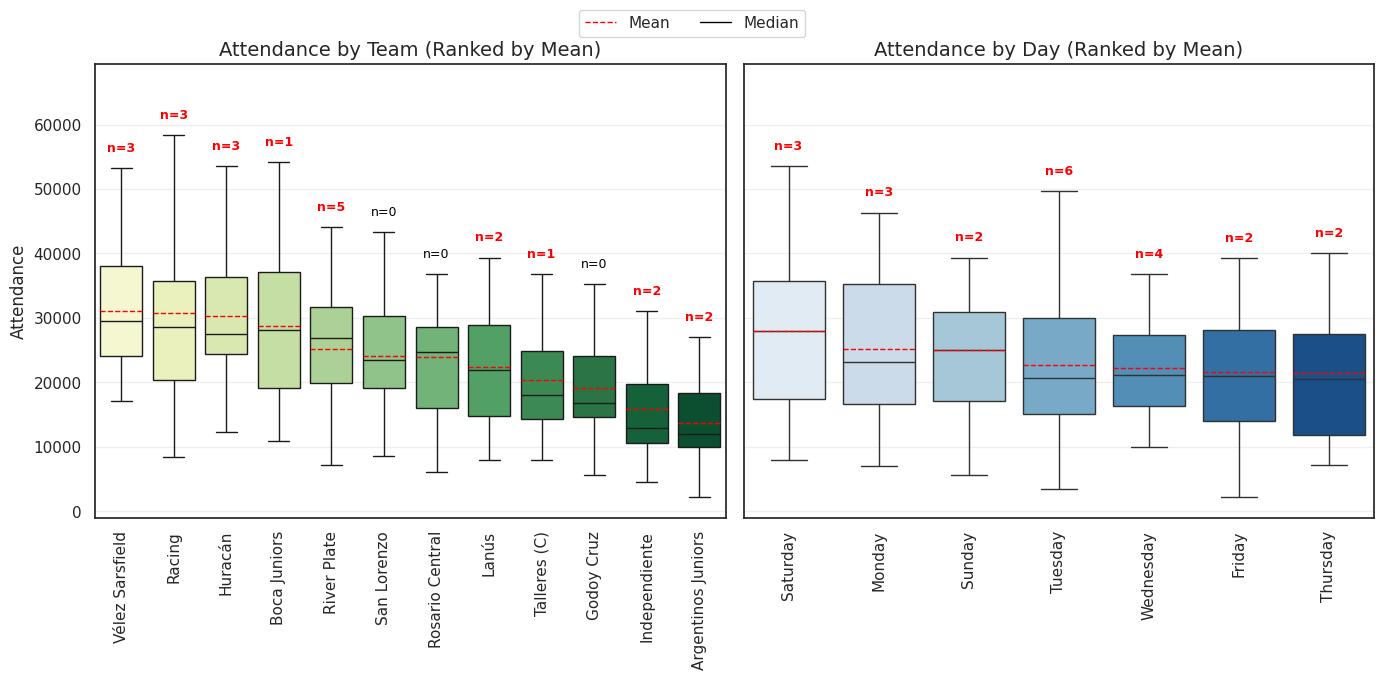

In [36]:
# calculate missing data points
missing_team_counts = data[data['attendance'].isna()]['team'].value_counts()
missing_day_counts = data[data['attendance'].isna()]['day'].value_counts()

# define sorting order for the boxplots (by mean)
team_order = data.groupby('team')['attendance'].mean().sort_values(ascending=False).index
day_order = data.groupby('day')['attendance'].mean().sort_values(ascending=False).index

# get the upper bound of the whisker to plot missing values label
def get_whisker_limit(series):
    if series.empty: return 0
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5 * IQR
    data_within_bound = series[series <= upper_bound]
    if not data_within_bound.empty:
        return data_within_bound.max()
    return series.max()

# add the missing values label and color them accordingly
def add_missing_labels(ax, data, category_col, order, counts):
    y_min, y_max = ax.get_ylim()
    offset = (y_max - y_min) * 0.03

    # for each element in team/days
    for i, category in enumerate(order):
      # get attendance counts
        count = counts.get(category, 0)
        cat_data = data[data[category_col] == category]['attendance'].dropna()

        # plot the count on top of the whisker
        if not cat_data.empty:
            whisker_top = get_whisker_limit(cat_data)
            label_text = f"n={count}"
            font_weight = 'bold' if count > 0 else 'normal'
            # shade red if missing values exist
            color = 'red' if count > 0 else 'black'
            ax.text(i, whisker_top + offset, label_text,
                    ha='center', va='bottom', fontsize=9,
                    color=color, fontweight=font_weight)

# plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7), sharey=True)

# properties for the dashed mean line
mean_line_props = {
    "linestyle": "--",
    "linewidth": 1,
    "color": "red"
}

# plot teams
sns.boxplot(data=data, x='team', y='attendance', order=team_order, ax=ax1,
            palette="YlGn", fliersize=0,
            showmeans=True, meanline=True, meanprops=mean_line_props)
# add missing values labels
add_missing_labels(ax1, data, 'team', team_order, missing_team_counts)

ax1.set_title("Attendance by Team (Ranked by Mean)", fontsize=14)
ax1.set_xlabel("")
ax1.set_ylabel("Attendance")
ax1.tick_params(axis='x', rotation=90)
ax1.grid(axis='y', alpha=0.3)

# plot days
sns.boxplot(data=data, x='day', y='attendance', order=day_order, ax=ax2,
            palette='Blues', fliersize=0,
            showmeans=True, meanline=True, meanprops=mean_line_props)
# add missing values labels
add_missing_labels(ax2, data, 'day', day_order, missing_day_counts)

ax2.set_title("Attendance by Day (Ranked by Mean)", fontsize=14)
ax2.set_xlabel("")
ax2.set_ylabel("")
ax2.tick_params(axis='x', rotation=90)
ax2.grid(axis='y', alpha=0.3)

# legend
legend_elements = [
    Line2D([0], [0], color='red', linestyle='--', lw=1, label='Mean'),
    Line2D([0], [0], color='black', linestyle='-', lw=1, label='Median')
]
fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 0.98), ncol=2)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

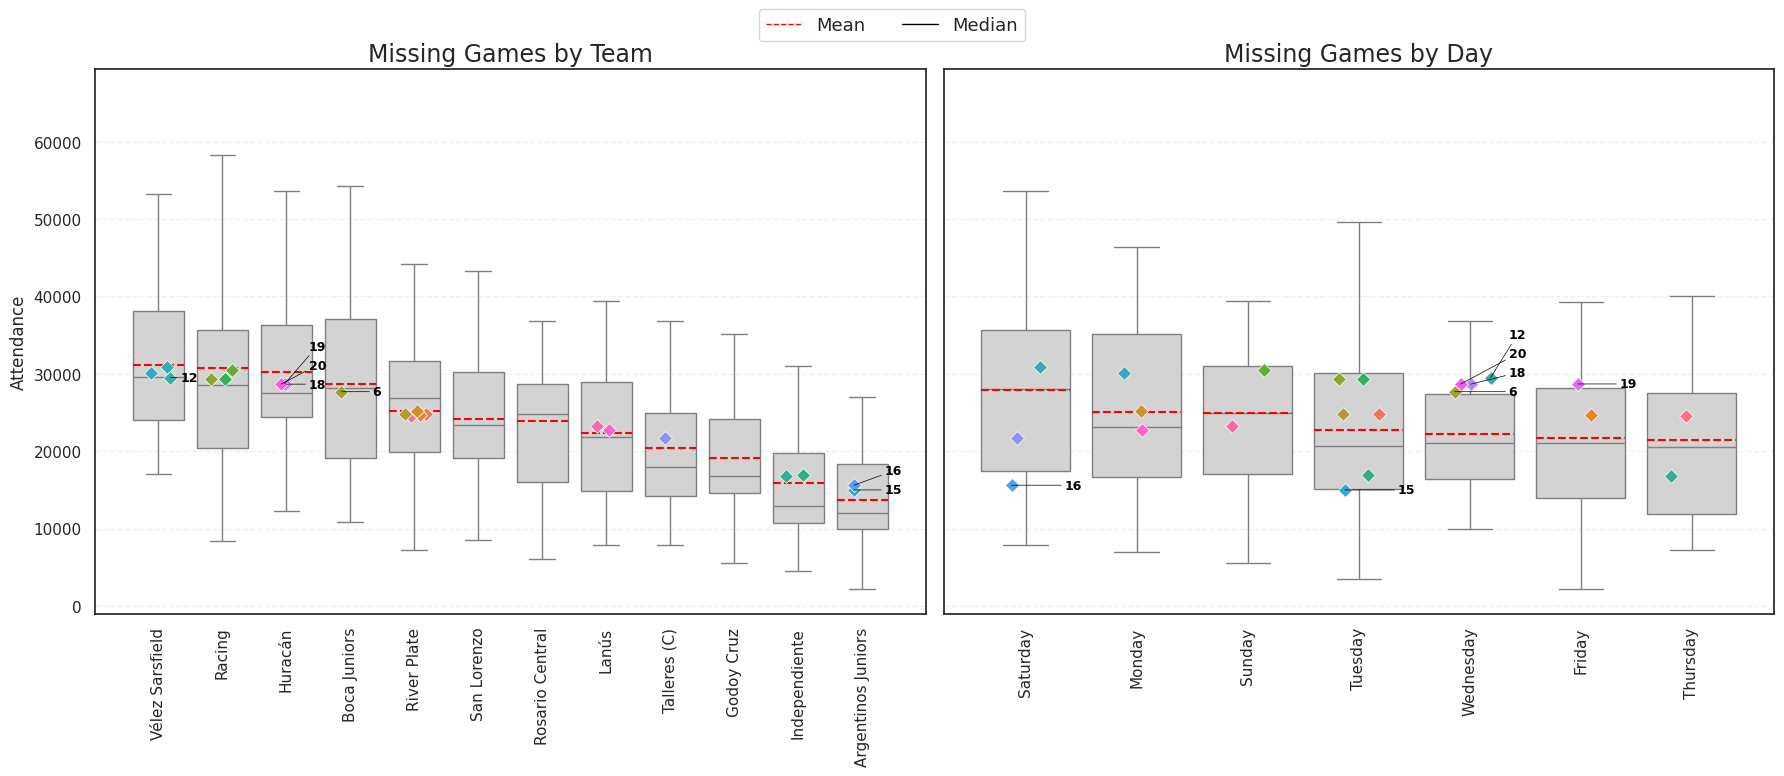

In [37]:
# final plot showing the predicted values

# identify missing rows
missing_mask = data['attendance'].isna()
missing_data = data[missing_mask].copy()

# setup prediction variables
teams_list = data['team'].unique()
days_list = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
team_map = {t: i for i, t in enumerate(teams_list)}
day_map = {d: i for i, d in enumerate(days_list)}

# getting the posterior samples and modifying their shape
post = samples_2_2.posterior
intercept_s = post['intercept'].values.flatten()
beta_s = post['beta'].values.reshape(len(intercept_s), -1)
gamma_s = post['gamma'].values.reshape(len(intercept_s), -1)

# storing the means for the boxplots
predicted_means = []

# for each missing datapoint get the prediction
for _, row in missing_data.iterrows():
    t_idx = team_map[row['team']]
    d_idx = day_map[row['day']]
    mu_samples = np.exp(intercept_s + beta_s[:, t_idx] + gamma_s[:, d_idx])
    predicted_means.append(np.mean(mu_samples))

missing_data['predicted_attendance'] = predicted_means
missing_data['game_id'] = range(1, len(missing_data) + 1)

# manual jitter for consistent x-coords
np.random.seed(42) # reproduction
missing_data['jitter_offset'] = np.random.uniform(-0.2, 0.2, size=len(missing_data))

# we need a way to organize the labels so they do not overlap
def repel_and_annotate(ax, category_data, x_center, category_col,
                       box_stats, outlier_check_func):
    # filter points to plot/label to ensure the plot is easy to read
    points_to_label = []

    for _, row in category_data.iterrows():
        x_real = x_center + row['jitter_offset']
        y_real = row['predicted_attendance']
        gid = row['game_id']
        color = unique_colors[gid - 1]

        # plot point
        ax.scatter(x_real, y_real, color=color, s=50, marker='D',
                   edgecolors='white', linewidth=0.5, zorder=10)

        # check for label requirement
        if outlier_check_func(row, box_stats):
            points_to_label.append({'x': x_real, 'y': y_real, 'id': gid, 'color': color})

    if not points_to_label:
        return

    # sort by y to stack labels
    points_to_label.sort(key=lambda k: k['y'])

    # calculate stacked y positions
    y_min, y_max = ax.get_ylim()
    min_dist = (y_max - y_min) * 0.035

    current_label_ys = []
    for i, p in enumerate(points_to_label):
        y = p['y']
        if i > 0:
            prev_y = current_label_ys[-1]
            if y < prev_y + min_dist:
                y = prev_y + min_dist
        current_label_ys.append(y)

    # draw lines and labels
    for p, label_y in zip(points_to_label, current_label_ys):
        text_x = x_center + 0.35
        ax.annotate(
            str(p['id']),
            xy=(p['x'], p['y']),
            xytext=(text_x, label_y),
            arrowprops=dict(arrowstyle="-", color='black', lw=0.5, shrinkA=0, shrinkB=0),
            fontsize=9, fontweight='bold', color='black',
            ha='left', va='center', zorder=20
        )


# calculate stats for outlier detection
team_stats = data.groupby('team')['attendance'].quantile([0.25, 0.75]).unstack()
day_stats = data.groupby('day')['attendance'].quantile([0.25, 0.75]).unstack()

# sort orders by mean
team_order = data.groupby('team')['attendance'].mean().sort_values(ascending=False).index
day_order = data.groupby('day')['attendance'].mean().sort_values(ascending=False).index

team_x_map = {team: i for i, team in enumerate(team_order)}
day_x_map = {day: i for i, day in enumerate(day_order)}

# color datapoints
unique_colors = sns.color_palette("husl", len(missing_data))

# plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8), sharey=True)

# plot 1: teams
mean_line_props = {
    "linestyle": "--",
    "linewidth": 1.5,
    "color": "red"
}

sns.boxplot(data=data, x='team', y='attendance', order=team_order,
            color='lightgrey', fliersize=0, ax=ax1,
            showmeans=True, meanline=True, meanprops=mean_line_props) # added meanline=True

for team, x_idx in team_x_map.items():
    cat_data = missing_data[missing_data['team'] == team]

    # outlier check: union of both views
    def check_team_outlier(row, stats):
        t_q1, t_q3 = stats.loc[row['team'], 0.25], stats.loc[row['team'], 0.75]
        d_q1, d_q3 = day_stats.loc[row['day'], 0.25], day_stats.loc[row['day'], 0.75]
        val = row['predicted_attendance']
        return (val < t_q1 or val > t_q3) or (val < d_q1 or val > d_q3)

    repel_and_annotate(ax1, cat_data, x_idx, 'team', team_stats, check_team_outlier)

ax1.set_title("Missing Games by Team", fontsize=17)
ax1.set_ylabel("Attendance", fontsize=12)
ax1.tick_params(axis='x', rotation=90)
ax1.set_xlabel("")
ax1.grid(axis='y', linestyle='--', alpha=0.3)

# plot 2: days
sns.boxplot(data=data, x='day', y='attendance', order=day_order,
            color='lightgrey', fliersize=0, ax=ax2,
            showmeans=True, meanline=True, meanprops=mean_line_props) # added meanline=True

for day, x_idx in day_x_map.items():
    cat_data = missing_data[missing_data['day'] == day]

    # outlier check: union of both views
    def check_day_outlier(row, stats):
        t_q1, t_q3 = team_stats.loc[row['team'], 0.25], team_stats.loc[row['team'], 0.75]
        d_q1, d_q3 = stats.loc[row['day'], 0.25], stats.loc[row['day'], 0.75]
        val = row['predicted_attendance']
        return (val < t_q1 or val > t_q3) or (val < d_q1 or val > d_q3)

    repel_and_annotate(ax2, cat_data, x_idx, 'day', day_stats, check_day_outlier)

ax2.set_title("Missing Games by Day", fontsize=17)
ax2.set_xlabel("")
ax2.set_ylabel("")
ax2.tick_params(axis='x', rotation=90)
ax2.grid(axis='y', linestyle='--', alpha=0.3)

# custom legend
legend_elements = [
    Line2D([0], [0], color='red', linestyle='--', lw=1, label='Mean'),
    Line2D([0], [0], color='black', linestyle='-', lw=1, label='Median')
]
fig.legend(handles=legend_elements, loc='upper center', fontsize=13, bbox_to_anchor=(0.5, 0.98), ncol=2)

# legend
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()